> **Unconstrained variant.** This copy deliberately ignores the assignment's GPU
> memory budget (5 GB in training, 4 GB at inference) in search of the best Panoptic
> Quality the pipeline can reach. Everything else is the same code as the main
> notebooks; see the configuration cell for the measured ladder of runs.

# Solar Filament Segmentation — training notebook

**Francesco Peluso** (`IE22700088`, f.peluso29@studenti.unisa.it)
Machine Learning A.Y. 2025/26 — MSc Computer Engineering, DIEM, University of Salerno
[filament-segmentation-2026](https://www.kaggle.com/competitions/filament-segmentation-2026)

This notebook trains one experiment and saves everything needed to reproduce it under
`experiments/<ID>/`: configuration, per-epoch history, the chosen threshold and
post-processing, plots and the best checkpoint. The Kaggle file itself is written by
`02_inference.ipynb`, which reads the recipe this notebook produces.

Two metrics are tracked, and they disagree in a useful way. **Dice** measures pixel
overlap and is what the course grades. **Panoptic Quality (PQ)** treats every connected
component as an instance, matches predictions to ground truth at IoU > 0.5, and is what
the Kaggle leaderboard reports. A filament broken in two, or a correct mask surrounded
by small spurious blobs, barely moves Dice but destroys PQ. The PQ used here is the
competition's own definition, re-implemented from the organisers'
`self-evaluation-notebook.ipynb` and checked against it (they agree to 3e-8), so the
validation numbers can be compared with the leaderboard directly.

To run an experiment: edit the **configuration cell** (section 3) and run everything
top to bottom. Nothing else needs to be touched.

## 1. Environment

The same notebook has to run on Colab (NVIDIA), on a MacBook (Apple Silicon) and on a
plain CPU. Instead of checking version numbers, the settings that actually differ
between backends — autocast dtype, gradient scaler, memory format, dataloader workers —
are probed once by just trying them.

In [1]:
import subprocess
import sys
from pathlib import Path

ON_COLAB = "google.colab" in sys.modules
if ON_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pycocotools"], check=False)


def locate_project() -> Path:
    """Find the project root from wherever this notebook was opened."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "dataset").is_dir() or (candidate / "experiments").is_dir():
            return candidate
    for candidate in (Path("/content/MachineLearning-Project"),
                      Path("/kaggle/working/MachineLearning-Project")):
        if candidate.is_dir():
            return candidate
    return Path.cwd()


PROJECT_ROOT = locate_project()

# The competition zip's own layout nests everything one level deeper
# (dataset/MAGFiLO_1.0_Kaggle_2026/train/...) than a plain "dataset/train/..." tree
# does. Both are accepted below, whichever a local copy or a kagglehub download hands
# back, so no extra path-fixing cell is ever needed.
def _has_dataset(root: Path) -> bool:
    return (root / "train").is_dir() or (root / "MAGFiLO_1.0_Kaggle_2026").is_dir()


DATASET_DIR = PROJECT_ROOT / "dataset"

if ON_COLAB and not _has_dataset(DATASET_DIR):
    # Nothing local yet (no Drive mount, no manual unzip): pull the competition data
    # straight from Kaggle. This needs Kaggle credentials available in the session
    # (Colab Secrets KAGGLE_USERNAME/KAGGLE_KEY, a kaggle.json, or kagglehub's own
    # interactive login) and the competition rules accepted on kaggle.com - if either
    # is missing, kagglehub raises its own clear error here rather than failing later
    # with a bare FileNotFoundError deep inside data loading.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)
    import kagglehub
    DATASET_DIR = Path(kagglehub.competition_download("filament-segmentation-2026"))
    print(f"downloaded competition data to {DATASET_DIR}")

if not (DATASET_DIR / "train").is_dir() and (DATASET_DIR / "MAGFiLO_1.0_Kaggle_2026").is_dir():
    DATASET_DIR = DATASET_DIR / "MAGFiLO_1.0_Kaggle_2026"
TRAIN_IMAGES = DATASET_DIR / "train" / "train_images"
ANNOTATIONS = DATASET_DIR / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
TEST_IMAGES = DATASET_DIR / "test" / "test_images"

print(f"project : {PROJECT_ROOT}")
print(f"dataset : {DATASET_DIR}  (exists: {DATASET_DIR.is_dir()})")
if not ANNOTATIONS.is_file():
    listing = sorted(p.name for p in DATASET_DIR.iterdir()) if DATASET_DIR.is_dir() else []
    print(f"WARNING: annotations not found at {ANNOTATIONS}")
    print(f"  contents of {DATASET_DIR}: {listing}")

100%|██████████| 671M/671M [00:03<00:00, 215MB/s]

Extracting files...


downloaded competition data to /root/.cache/kagglehub/competitions/filament-segmentation-2026
project : /content
dataset : /root/.cache/kagglehub/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026  (exists: True)


In [2]:
import json
import os
import platform
import random
import sys
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from scipy import ndimage
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 22


def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class Runtime:
    """Everything that depends on the accelerator we happen to be running on
    (CUDA on Colab, MPS on a MacBook, or plain CPU), probed once at start-up."""

    def __init__(self, num_workers=None):
        if torch.cuda.is_available():
            self.device = torch.device("cuda")
            torch.backends.cudnn.benchmark = True
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
            self.device = torch.device("mps")
            torch.set_float32_matmul_precision("high")
        else:
            self.device = torch.device("cpu")

        self.amp_dtype, self.needs_scaler = self._probe_autocast()
        self.channels_last = self.device.type == "cuda"
        self.pin_memory = self.device.type == "cuda"
        # With the uint8 cache in place one process already feeds ~160 samples/s,
        # more than any of these GPUs can consume, so workers only pay off on
        # CUDA hosts where fork is cheap.
        cpus = os.cpu_count() or 2
        self.num_workers = num_workers if num_workers is not None else (
            min(4, max(0, cpus - 2)) if self.device.type == "cuda" else 0)
        self._peak = 0

    def _probe_autocast(self):
        if self.device.type == "cpu":
            return None, False
        for dtype in (torch.bfloat16, torch.float16):
            try:
                with torch.autocast(device_type=self.device.type, dtype=dtype):
                    probe = torch.ones(8, 8, device=self.device)
                    if float((probe @ probe).float().sum()) != 512.0:
                        continue
            except Exception:
                continue
            return dtype, dtype is torch.float16 and self.device.type == "cuda"
        return None, False

    def autocast(self):
        return (nullcontext() if self.amp_dtype is None
                else torch.autocast(device_type=self.device.type, dtype=self.amp_dtype))

    def grad_scaler(self):
        return torch.amp.GradScaler(self.device.type, enabled=self.needs_scaler)

    def prepare(self, obj):
        obj = obj.to(self.device, non_blocking=self.pin_memory)
        if self.channels_last and (not torch.is_tensor(obj) or obj.dim() == 4):
            obj = obj.to(memory_format=torch.channels_last)
        return obj

    def loader_kwargs(self, batch_size):
        kwargs = {"batch_size": batch_size, "num_workers": self.num_workers,
                  "pin_memory": self.pin_memory}
        if self.num_workers:
            # Workers must be recreated at every epoch. FilamentDataset.set_epoch()
            # changes the deterministic crop/augmentation seed in the main process;
            # persistent workers would keep their private epoch-0 dataset copy and
            # therefore repeat the same crop, flips and photometric transform forever.
            kwargs.update(persistent_workers=False, prefetch_factor=4)
        return kwargs

    # Peak memory: the assignment gives a bonus below 5 GB training / 4 GB test.
    # CUDA tracks the peak itself; MPS has no peak counter and its pool figure
    # over-reports, so live allocation is sampled at the point a step peaks.
    def reset_peak_memory(self):
        self._peak = 0
        if self.device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        elif self.device.type == "mps":
            torch.mps.empty_cache()

    def note_memory(self):
        if self.device.type == "mps":
            self._peak = max(self._peak, torch.mps.current_allocated_memory())

    def peak_memory_gb(self):
        """Peak of live tensors: comparable across backends, the figure to quote."""
        if self.device.type == "cuda":
            return torch.cuda.max_memory_allocated() / 1024 ** 3
        if self.device.type == "mps":
            return (self._peak or torch.mps.driver_allocated_memory()) / 1024 ** 3
        return float("nan")

    def reserved_memory_gb(self):
        """What the allocator holds, cache included: a conservative upper bound.

        In inference the live figure under-reports, because nothing keeps the
        activations alive long enough to be sampled between steps; this one does
        not have that problem.
        """
        if self.device.type == "cuda":
            return torch.cuda.max_memory_reserved() / 1024 ** 3
        if self.device.type == "mps":
            return torch.mps.driver_allocated_memory() / 1024 ** 3
        return float("nan")

    def summary(self):
        name = (torch.cuda.get_device_name(0) if self.device.type == "cuda"
                else f"Apple Silicon GPU ({platform.machine()})" if self.device.type == "mps"
                else platform.processor() or "CPU")
        dtype = str(self.amp_dtype).replace("torch.", "") if self.amp_dtype else "disabled"
        return (f"device       : {self.device} ({name})\n"
                f"autocast     : {dtype}{' + GradScaler' if self.needs_scaler else ''}\n"
                f"channels_last: {self.channels_last} | dataloader workers: {self.num_workers}\n"
                f"torch {torch.__version__} | python {sys.version.split()[0]}")

    def info(self):
        return {"device": str(self.device), "autocast": str(self.amp_dtype),
                "channels_last": self.channels_last, "num_workers": self.num_workers,
                "torch": torch.__version__, "python": sys.version.split()[0],
                "platform": platform.platform()}


seed_everything()
runtime = Runtime()
print(runtime.summary())

device       : cuda (NVIDIA A100-SXM4-40GB)
autocast     : bfloat16
channels_last: True | dataloader workers: 4
torch 2.11.0+cu128 | python 3.12.13


## 2. Data and the split

The annotations are in COCO format, with a twist: each entry of `images` is **one
annotator's view** of an observation, identified as `<annotator>-<file stem>`. The same
JPEG can appear two or three times with different polygons, because the annotators
disagree on where a filament starts and ends. Those disagreements are kept: the official
metric scores a prediction against every annotator separately.

The train/validation/test split is done on **file names**, never on annotator records:
two annotators of the same image describe the same pixels, so splitting on records would
leak validation pixels into training and inflate every score.

In [3]:
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass

NATIVE = 2048


@dataclass
class Sample:
    image_id: str          # "<annotator>-<file stem>", the competition's own identifier
    file_name: str
    image_path: Path
    width: int
    height: int
    polygons: list


def load_coco(annotations_path, images_dir):
    """Each entry of `images` is one annotator's view of one observation."""
    with Path(annotations_path).open(encoding="utf-8") as handle:
        coco = json.load(handle)

    polygons_by_image = defaultdict(list)
    for annotation in coco["annotations"]:
        for polygon in annotation.get("segmentation", []):
            if len(polygon) >= 6:              # a polygon needs at least three points
                polygons_by_image[annotation["image_id"]].append(polygon)

    samples = [Sample(info["id"], info["file_name"], Path(images_dir) / info["file_name"],
                      info["width"], info["height"], polygons_by_image[info["id"]])
               for info in coco["images"]]
    missing = [s.image_path for s in samples if not s.image_path.is_file()]
    if missing:
        raise FileNotFoundError(f"{len(missing)} images missing, first: {missing[0]}")
    return samples


def split_by_file(samples, train_fraction=0.70, validation_fraction=0.15, seed=SEED):
    """Split on file names, never on records.

    Two annotators of the same observation describe the same pixels; splitting on
    records would put one copy in training and another in validation and inflate
    every score without improving the model at all.
    """
    file_names = sorted({s.file_name for s in samples})
    random.Random(seed).shuffle(file_names)
    train_end = int(len(file_names) * train_fraction)
    validation_end = train_end + int(len(file_names) * validation_fraction)
    files = {"train": set(file_names[:train_end]),
             "validation": set(file_names[train_end:validation_end]),
             "test": set(file_names[validation_end:])}
    by_split = {name: [s for s in samples if s.file_name in group]
                for name, group in files.items()}
    return by_split, files


def rasterize(width, height, polygons, size=None):
    mask = Image.new("L", (width, height), 0)
    drawer = ImageDraw.Draw(mask)
    for polygon in polygons:
        drawer.polygon([(polygon[i], polygon[i + 1]) for i in range(0, len(polygon), 2)], fill=1)
    if size is not None and (width, height) != (size, size):
        mask = mask.resize((size, size), resample=Image.Resampling.NEAREST)
    return np.asarray(mask, dtype=np.uint8)


def rasterize_instances(width, height, polygons, size=None):
    """One label per polygon: the GT instances the metric counts, for the loss.

    The dataset has at most 26 polygons per annotator record, so uint8 is enough.
    Overlapping polygons are rare and the later one wins; a loss term does not
    need the disputed sliver, the metric keeps scoring both instances in full.
    """
    mask = Image.new("L", (width, height), 0)
    drawer = ImageDraw.Draw(mask)
    for value, polygon in enumerate(polygons, start=1):
        drawer.polygon([(polygon[i], polygon[i + 1]) for i in range(0, len(polygon), 2)],
                       fill=value)
    if size is not None and (width, height) != (size, size):
        mask = mask.resize((size, size), resample=Image.Resampling.NEAREST)
    return np.asarray(mask, dtype=np.uint8)


def load_image(path, size=None):
    with Image.open(path) as handle:
        image = handle.convert("L")
        if size is not None and image.size != (size, size):
            image = image.resize((size, size), resample=Image.Resampling.BILINEAR)
        return np.asarray(image, dtype=np.uint8)


class SampleCache:
    """Images and masks decoded once into uint8 memory-mapped files on disk,
    shared across runs. Masks are bit-packed (8 pixels per byte)."""

    def __init__(self, samples, size, cache_dir, workers=None, soft=False,
                 instances=False):
        self.dir = Path(cache_dir)
        self.dir.mkdir(parents=True, exist_ok=True)
        self.size = size
        file_names = sorted({s.file_name for s in samples})
        self.file_row = {name: i for i, name in enumerate(file_names)}
        self.record_row = {s.image_id: i for i, s in enumerate(samples)}
        self._images = self._masks = self._soft = self._labels = None
        self.has_soft = bool(soft)
        self.has_instances = bool(instances)

        index_path = self.dir / f"index_{size}.json"
        images_path = self.dir / f"images_{size}.u8"
        masks_path = self.dir / f"masks_{size}.u8"
        soft_path = self.dir / f"soft_{size}.u8"
        labels_path = self.dir / f"labels_{size}.u8"
        index = {"size": size, "files": file_names, "records": [s.image_id for s in samples],
                 "soft": self.has_soft}
        if self.has_instances:
            # only stamped when requested, so caches built before this flag existed
            # stay valid for every run that does not need instance labels
            index["instances"] = True
        stored = json.loads(index_path.read_text()) if index_path.is_file() else None
        if stored is not None and not self.has_instances:
            stored.pop("instances", None)
        if (stored == index and images_path.is_file() and masks_path.is_file()
                and (soft_path.is_file() or not self.has_soft)
                and (labels_path.is_file() or not self.has_instances)):
            return

        images = np.lib.format.open_memmap(images_path, mode="w+", dtype=np.uint8,
                                           shape=(len(file_names), size, size))
        masks = np.lib.format.open_memmap(masks_path, mode="w+", dtype=np.uint8,
                                          shape=(len(samples), size * size // 8))
        soft = (np.lib.format.open_memmap(soft_path, mode="w+", dtype=np.uint8,
                                          shape=(len(file_names), size, size))
                if self.has_soft else None)
        labels = (np.lib.format.open_memmap(labels_path, mode="w+", dtype=np.uint8,
                                            shape=(len(samples), size, size))
                  if self.has_instances else None)
        path_by_file = {s.file_name: s.image_path for s in samples}
        records_by_file = defaultdict(list)
        for sample in samples:
            records_by_file[sample.file_name].append(sample)

        # Threads, not processes: JPEG decoding and polygon rasterisation release
        # the GIL, and unlike `spawn` this behaves the same in a script, a
        # notebook, Colab and Kaggle.
        def do_image(item):
            i, name = item
            images[i] = load_image(path_by_file[name], size)

        def do_mask(item):
            i, sample = item
            masks[i] = np.packbits(rasterize(sample.width, sample.height, sample.polygons, size))

        def do_labels(item):
            i, sample = item
            labels[i] = rasterize_instances(sample.width, sample.height,
                                            sample.polygons, size)

        def do_soft(item):
            """The fraction of this observation's annotators covering each pixel.

            Averaged at native resolution and only then resized, with an antialiased
            filter: a boundary pixel half of the panel included arrives as 0.5 instead of
            being rounded to whichever annotator the nearest-neighbour grid happened to
            land on.
            """
            i, name = item
            records = records_by_file[name]
            total = np.zeros((NATIVE, NATIVE), dtype=np.float32)
            for sample in records:
                total += rasterize(sample.width, sample.height, sample.polygons)
            plane = Image.fromarray((total * (255.0 / len(records))).astype(np.uint8))
            if size != NATIVE:
                plane = plane.resize((size, size), resample=Image.Resampling.BILINEAR)
            soft[i] = np.asarray(plane, dtype=np.uint8)

        with ThreadPoolExecutor(max_workers=workers or min(8, os.cpu_count() or 4)) as pool:
            list(tqdm(pool.map(do_image, enumerate(file_names)), total=len(file_names),
                      desc=f"cache images @{size}", leave=False))
            list(tqdm(pool.map(do_mask, enumerate(samples)), total=len(samples),
                      desc=f"cache masks @{size}", leave=False))
            if self.has_soft:
                list(tqdm(pool.map(do_soft, enumerate(file_names)), total=len(file_names),
                          desc=f"cache soft targets @{size}", leave=False))
            if self.has_instances:
                list(tqdm(pool.map(do_labels, enumerate(samples)), total=len(samples),
                          desc=f"cache instance labels @{size}", leave=False))
        images.flush(); masks.flush()
        if soft is not None:
            soft.flush()
        if labels is not None:
            labels.flush()
        del images, masks, soft, labels
        index_path.write_text(json.dumps(index), encoding="utf-8")

    def _open(self):
        if self._images is None:
            self._images = np.load(self.dir / f"images_{self.size}.u8", mmap_mode="r")
            self._masks = np.load(self.dir / f"masks_{self.size}.u8", mmap_mode="r")
            if self.has_soft:
                self._soft = np.load(self.dir / f"soft_{self.size}.u8", mmap_mode="r")
            if self.has_instances:
                self._labels = np.load(self.dir / f"labels_{self.size}.u8", mmap_mode="r")

    def image(self, file_name):
        self._open()
        return np.asarray(self._images[self.file_row[file_name]])

    def mask(self, image_id):
        self._open()
        return np.unpackbits(self._masks[self.record_row[image_id]]).reshape(self.size, self.size)

    def soft(self, file_name):
        """Consensus target for an observation, as 0-255 = fraction of annotators."""
        self._open()
        return np.asarray(self._soft[self.file_row[file_name]])

    def labels(self, image_id):
        """Instance labels of one annotator record: 0 background, 1..k per polygon."""
        self._open()
        return np.asarray(self._labels[self.record_row[image_id]])

    def nbytes(self):
        keys = ["images", "masks"]
        if self.has_soft:
            keys.append("soft")
        if self.has_instances:
            keys.append("labels")
        return sum((self.dir / f"{k}_{self.size}.u8").stat().st_size for k in keys)


class SegmentationTransform:
    """Label-preserving augmentation applied to image and mask together.

    Filaments have no canonical orientation, so the eight symmetries of the
    square are free data. Photometric jitter exists because H-alpha contrast
    changes between observations; `scale_jitter` makes the network tolerant of a
    test-time scale different from the training one.
    """

    def __init__(self, augment=False, photometric=True, scale_jitter=None, soft=False,
                 crop=None):
        self.augment, self.photometric, self.scale_jitter = augment, photometric, scale_jitter
        self.soft = soft       # a soft target arrives as 0-255 and must interpolate, not snap
        self.crop = crop       # train on a window of the native frame, not a shrunken copy

    def __call__(self, image, mask, rng):
        if self.augment and self.crop and self.crop < image.shape[0]:
            image, mask = self._window(image, mask, rng)
        if self.augment and self.scale_jitter is not None:
            image, mask = self._rescale(image, mask, rng)
        if self.augment:
            if rng.random() < 0.5:
                image, mask = image[:, ::-1], mask[:, ::-1]
            if rng.random() < 0.5:
                image, mask = image[::-1], mask[::-1]
            turns = rng.randint(0, 3)
            if turns:
                image, mask = np.rot90(image, turns), np.rot90(mask, turns)

        image = np.ascontiguousarray(image, dtype=np.float32) / 255.0
        if self.augment and self.photometric:
            image *= 1.0 + rng.uniform(-0.20, 0.20)
            mean = float(image.mean())
            image = (image - mean) * (1.0 + rng.uniform(-0.20, 0.20)) + mean
            if rng.random() < 0.30:
                # Use the sample/epoch RNG here too: global NumPy state depends on
                # worker scheduling and makes otherwise deterministic runs diverge.
                noise = np.random.default_rng(rng.randrange(2 ** 32))
                image += noise.standard_normal(image.shape, dtype=np.float32) * 0.02
            np.clip(image, 0.0, 1.0, out=image)

        mask = np.ascontiguousarray(mask, dtype=np.float32)
        if self.soft:
            mask /= 255.0
        return torch.from_numpy(image).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)

    def _window(self, image, mask, rng):
        """A random crop x crop window of the full-resolution frame.

        Downscaling the image to fit memory destroys exactly the small filaments
        the model already struggles with; a window keeps every pixel at its
        annotated scale and gives up field of view instead, which is cheap
        because filaments are local structures.
        """
        size = image.shape[0]
        top, left = rng.randint(0, size - self.crop), rng.randint(0, size - self.crop)
        return (image[top:top + self.crop, left:left + self.crop],
                mask[top:top + self.crop, left:left + self.crop])

    def _rescale(self, image, mask, rng):
        size = image.shape[0]
        scaled = max(64, int(round(size * rng.uniform(*self.scale_jitter))))
        if scaled == size:
            return image, mask
        image = np.asarray(Image.fromarray(image).resize((scaled, scaled), Image.Resampling.BILINEAR))
        resample = Image.Resampling.BILINEAR if self.soft else Image.Resampling.NEAREST
        mask = np.asarray(Image.fromarray(mask).resize((scaled, scaled), resample))
        if scaled > size:
            top, left = rng.randint(0, scaled - size), rng.randint(0, scaled - size)
            return image[top:top + size, left:left + size], mask[top:top + size, left:left + size]
        pad = size - scaled
        top, left = rng.randint(0, pad), rng.randint(0, pad)
        spec = ((top, pad - top), (left, pad - left))
        return np.pad(image, spec), np.pad(mask, spec)


class FilamentDataset(Dataset):
    def __init__(self, samples, cache, transform, seed=SEED, instance_targets=False):
        self.samples, self.cache, self.transform, self.seed = samples, cache, transform, seed
        # With instance targets the mask tensor carries the label image (0..k per
        # polygon) instead of 0/1. Geometric augmentation is label-safe as long as
        # nothing interpolates mask values; scale jitter does, so it is excluded.
        self.instance_targets = instance_targets
        if instance_targets:
            assert transform.scale_jitter is None, \
                "scale jitter interpolates instance labels"
            assert not transform.soft, "soft and instance targets are exclusive"
        self._epoch = 0

    def set_epoch(self, epoch):
        self._epoch = epoch

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        rng = random.Random((self.seed, self._epoch, index).__hash__())
        target = (self.cache.labels(sample.image_id) if self.instance_targets
                  else self.cache.mask(sample.image_id))
        image, mask = self.transform(self.cache.image(sample.file_name), target, rng)
        return {"image": image, "mask": mask,
                "file_name": sample.file_name, "image_id": sample.image_id}


class SoftConsensusDataset(Dataset):
    """One sample per observation, with the annotators averaged into a soft target.

    `FilamentDataset` emits one sample per annotator, so an observation labelled by three
    people enters every epoch three times with three hard masks that contradict each
    other. Measured on this dataset that contradiction is not a detail: of the pixels at
    least one annotator calls filament, only 40% are called filament by all of them, and
    on the three-annotator files only 30%. A hard 0/1 target gives the network no way to
    say a pixel is genuinely borderline, so it can only average the conflict out across
    epochs, as gradient noise.

    Here the target is the fraction of annotators covering each pixel. The disagreement
    becomes the label instead of noise on top of it, and the number the network learns to
    output means something concrete - how much of the panel would include this pixel -
    which is also what makes a probability threshold a meaningful thing to search over.

    The validation set deliberately keeps `FilamentDataset` and its per-annotator hard
    masks, so every score stays comparable with the earlier experiments and the official
    metric is untouched.
    """

    def __init__(self, samples, cache, transform, seed=SEED):
        self.files = sorted({s.file_name for s in samples})
        self.annotators = Counter(s.file_name for s in samples)
        self.cache, self.transform, self.seed = cache, transform, seed
        self._epoch = 0

    def set_epoch(self, epoch):
        self._epoch = epoch

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file_name = self.files[index]
        rng = random.Random((self.seed, self._epoch, index).__hash__())
        image, mask = self.transform(self.cache.image(file_name),
                                     self.cache.soft(file_name), rng)
        return {"image": image, "mask": mask,
                "file_name": file_name, "image_id": Path(file_name).stem}


In [4]:
samples = load_coco(ANNOTATIONS, TRAIN_IMAGES)
by_split, files_by_split = split_by_file(samples)

assert files_by_split["train"].isdisjoint(files_by_split["validation"])
assert files_by_split["train"].isdisjoint(files_by_split["test"])
assert files_by_split["validation"].isdisjoint(files_by_split["test"])

records_per_file = Counter(s.file_name for s in samples)
print(f"unique JPEG files : {len(records_per_file)}")
print(f"COCO records      : {len(samples)}")
print(f"filament polygons : {sum(len(s.polygons) for s in samples)}")
print(f"annotators/file   : {dict(sorted(Counter(records_per_file.values()).items()))}\n")
for name in ("train", "validation", "test"):
    print(f"{name:11s}: {len(files_by_split[name]):3d} files, {len(by_split[name]):3d} records, "
          f"{sum(len(s.polygons) for s in by_split[name]):4d} polygons")

# The assignment asks for the split protocol as a CSV of sample names.
import csv
split_csv = PROJECT_ROOT / "splits" / f"split_seed{SEED}.csv"
split_csv.parent.mkdir(parents=True, exist_ok=True)
with split_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["file_name", "split"])
    for name in ("train", "validation", "test"):
        for file_name in sorted(files_by_split[name]):
            writer.writerow([file_name, name])
print(f"\nwritten: {split_csv.relative_to(PROJECT_ROOT)}")

unique JPEG files : 707
COCO records      : 1154
filament polygons : 8199
annotators/file   : {1: 411, 2: 145, 3: 151}

train      : 494 files, 806 records, 5856 polygons
validation : 106 files, 169 records, 1144 polygons
test       : 107 files, 179 records, 1199 polygons

written: splits/split_seed22.csv


## 3. Configuration

**The only cell to edit between experiments.** One change per run — loss *or*
resolution *or* augmentation, never several at once — otherwise the comparison with the
previous experiments means nothing.

As committed, this cell reproduces **experiment 08**, the model behind the submitted
`submission.csv`: it reuses the trained checkpoint (`RUN_TRAINING = False`), re-derives
the operating point on validation and writes the same recipe the submission was made
with. Set `RUN_TRAINING = True` to retrain from scratch (GPU training is not perfectly
reproducible, so a retrained model will differ slightly).

In [5]:
EXPERIMENT_ID = "U2"

# Unconstrained variant: the assignment's VRAM budget (5 GB training, 4 GB test) is
# deliberately ignored here. The one thing that budget actually prevented was
# training on the WHOLE native 2048 frame: experiment 13 tried random 1536 windows
# of it and lost the full-disk context (PQ 0.4066 vs 0.4264); a full 2048 frame
# keeps both the native pixels and the context. Ladder, one variable per run, each
# compared against experiment 08 (PQ 0.4264: 1536 full frame, ResNet18):
#   U1  IMAGE_SIZE = 2048, full frame, ResNet18        (PQ 0.4211, public LB 0.36)
#   U2  + MODEL_NAME = "resnet34"                      <- this file as committed
#   U3  + GRADIENT_CHECKPOINTING = False               (speed only, needs ~14 GB)
# Expected training peak at 2048 x batch 2: ~9-10 GB with checkpointing (fits a
# 16 GB T4), ~14 GB without. Inference at 2048 with TTA: ~4.5 GB.
RUN_TRAINING = True
INIT_FROM_CHECKPOINT = None    # path to a checkpoint to warm-start from, or None
RUN_TTA = True                 # average the 8 square symmetries at prediction time
RUN_FINAL_TEST = False         # look at the internal test split: only once, at the end

# --- resolution ----------------------------------------------------------------
IMAGE_SIZE = 2048              # native: no resize anywhere in the pipeline
TRAIN_CROP = 2048              # == IMAGE_SIZE: the whole frame, no window
INFERENCE_TILE = None          # whole frame in one pass

# --- data ----------------------------------------------------------------------
BATCH_SIZE = 2
GRADIENT_CHECKPOINTING = True  # keeps the 2048 step inside a 16 GB card
GRAD_ACCUM_STEPS = 1
MICRO_BATCH_SIZE = BATCH_SIZE // GRAD_ACCUM_STEPS
assert BATCH_SIZE % GRAD_ACCUM_STEPS == 0, "BATCH_SIZE must divide evenly"
assert TRAIN_CROP <= IMAGE_SIZE, "the training window cannot exceed the cached frame"
PHOTOMETRIC = True             # brightness/contrast jitter: H-alpha contrast varies
SCALE_JITTER = None            # falsified in experiment 10, keep None
SOFT_TARGETS = False           # falsified in experiment 12, keep False
TRAIN_ON_TEST_SPLIT = True     # +22% training data; validation stays held out

# --- model and loss --------------------------------------------------------------
MODEL_NAME = "resnet34"        # "resnet18" | "resnet34" | "unet"
PRETRAINED = True
# "bce_dice" | "bce_dice_instance" | "tversky_cldice" | "bce_dice_cldice".
# bce_dice is the proven recipe; the instance-balanced variant was falsified as a
# dominant term (experiment 14) and a positive-class weight of 20 traded its
# recall gain for false positives (experiment 15). Both knobs stay available.
LOSS_NAME = "bce_dice"
POS_WEIGHT = None
INSTANCE_TARGETS = LOSS_NAME == "bce_dice_instance"

# --- optimisation ----------------------------------------------------------------
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 20
USE_COSINE = True
PATIENCE = 8
MIN_DELTA = 1e-3

# The Kaggle leaderboard reports PQ and nothing else, so the recipe is frozen on PQ.
SELECTION_OBJECTIVE = "pq"     # "balanced" | "pq" | "dice"

if TRAIN_ON_TEST_SPLIT and RUN_FINAL_TEST:
    raise ValueError("the test split cannot be both trained on and used as a held-out set")

EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / EXPERIMENT_ID
METRICS_DIR, PLOTS_DIR = EXPERIMENT_DIR / "metrics", EXPERIMENT_DIR / "plots"
CHECKPOINTS_DIR = EXPERIMENT_DIR / "checkpoints"
for directory in (METRICS_DIR, PLOTS_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
# best_model.pt follows validation Dice; a second checkpoint follows the cheap
# per-epoch PQ. The final search compares both and keeps the winner.
BEST_DICE_CHECKPOINT = CHECKPOINTS_DIR / "best_model.pt"
BEST_PQ_CHECKPOINT = CHECKPOINTS_DIR / "best_pq_model.pt"
BEST_CHECKPOINT = BEST_DICE_CHECKPOINT


def save_json(data, path):
    Path(path).write_text(json.dumps(data, indent=2, default=float), encoding="utf-8")


print(f"artifacts -> {EXPERIMENT_DIR.relative_to(PROJECT_ROOT)}")
print(f"{MODEL_NAME} on {IMAGE_SIZE}px full frames | "
      f"{'retraining' if RUN_TRAINING else 'reusing checkpoint'} | objective {SELECTION_OBJECTIVE}")

artifacts -> experiments/15
train 1536px window of a 1536px frame | retraining | objective pq


## 4. The uint8 cache

Decoding a 2048×2048 JPEG and rasterising its polygons costs more than a forward+backward
pass of the network. Done inside `Dataset.__getitem__`, that price is paid once per
sample *per epoch* and the pipeline becomes I/O-bound. So everything is decoded once
into memory-mapped uint8 arrays on disk and reused across runs.

In [6]:
started = time.perf_counter()
cache = SampleCache(samples, IMAGE_SIZE, PROJECT_ROOT / ".cache", soft=SOFT_TARGETS,
                    instances=INSTANCE_TARGETS)
print(f"cache at {IMAGE_SIZE}x{IMAGE_SIZE}: {cache.nbytes() / 1e6:.0f} MB on disk, "
      f"ready in {time.perf_counter() - started:.1f}s")

cache images @1536:   0%|          | 0/707 [00:00<?, ?it/s]

cache masks @1536:   0%|          | 0/1154 [00:00<?, ?it/s]

cache at 1536x1536: 2008 MB on disk, ready in 12.8s


## 5. A quick look at the data

Filaments are dark, thin, irregular, and cover well under 1% of the pixels — which is
why the loss needs a Dice term. 296 files have two or three independent annotations,
and the mean Dice **between two annotators of the same image** is a practical ceiling:
above it, a model is just imitating one expert's style.

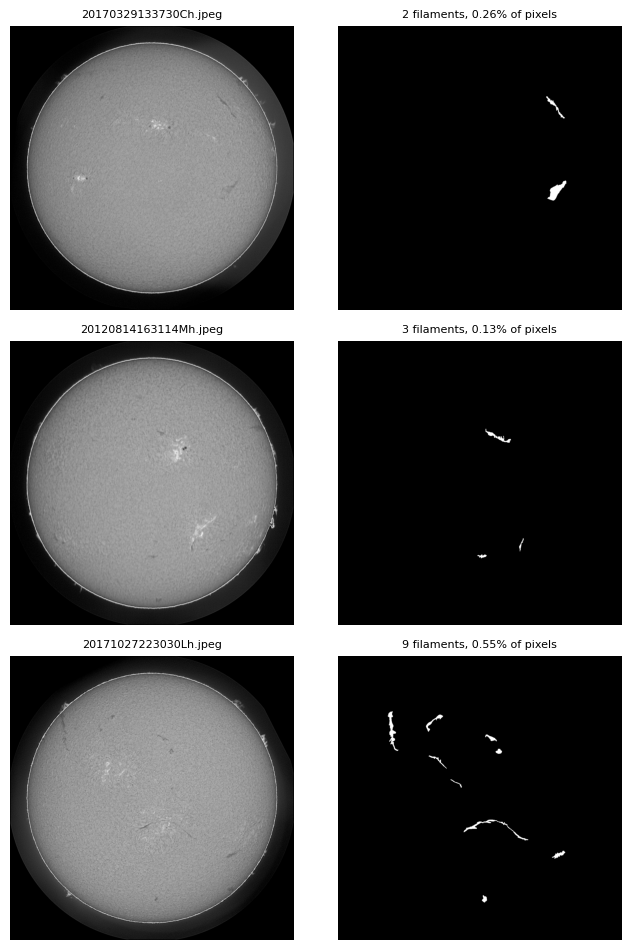

annotation pairs on the same file : 598
mean inter-annotator Dice         : 0.6207 (median 0.6493)


In [7]:
import matplotlib.pyplot as plt

chosen = random.Random(SEED).sample(by_split["train"], 3)
figure, axes = plt.subplots(3, 2, figsize=(7, 9.6), squeeze=False)
for row, sample in enumerate(chosen):
    axes[row, 0].imshow(cache.image(sample.file_name), cmap="gray")
    axes[row, 0].set_title(sample.file_name, fontsize=8)
    mask = cache.mask(sample.image_id)
    axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"{len(sample.polygons)} filaments, {100 * mask.mean():.2f}% of pixels",
                           fontsize=8)
    for axis in axes[row]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(PLOTS_DIR / "dataset_examples.png", dpi=160, bbox_inches="tight")
plt.show()

by_file = defaultdict(list)
for sample in samples:
    by_file[sample.file_name].append(sample)
agreement = []
for records in by_file.values():
    if len(records) < 2:
        continue
    masks = [cache.mask(r.image_id).astype(bool) for r in records]
    for i in range(len(masks)):
        for j in range(i + 1, len(masks)):
            overlap = np.logical_and(masks[i], masks[j]).sum()
            agreement.append((2 * overlap + 1e-6) / (masks[i].sum() + masks[j].sum() + 1e-6))
agreement = np.asarray(agreement)
print(f"annotation pairs on the same file : {len(agreement)}")
print(f"mean inter-annotator Dice         : {agreement.mean():.4f} "
      f"(median {np.median(agreement):.4f})")

## 6. Model and loss

The model is a **U-Net with a ResNet18 encoder pre-trained on ImageNet**. With fewer
than 500 training observations, learning basic edges and textures from scratch is a
waste of the data budget, so the encoder starts from ImageNet; the U-Net decoder's skip
connections carry the fine detail thin filaments need.

One implementation note: the usual way to feed grayscale into an ImageNet encoder is to
repeat the channel three times and normalise with the RGB statistics. Written out, that
is just a 1-channel convolution plus a constant, and the constant gets absorbed by the
batch norm right after — so the stem is folded into an exactly equivalent single-channel
one, and the input tensor shrinks by 3×.

The default loss is `0.5·BCE + 0.5·soft Dice`: BCE keeps the probabilities calibrated
(which the threshold search later relies on), Dice handles the extreme class imbalance.
Two alternatives are implemented behind the `LOSS_NAME` flag: an **instance-balanced
Dice** (`bce_dice_instance`, experiment 14) where every filament weighs the same
regardless of its area, and a `POS_WEIGHT` on the BCE (experiment 15) against the
tendency of unweighted BCE to shrink predictions when positives are 0.4% of the pixels.

In [8]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat((skip, x), dim=1))


class UNet(nn.Module):
    """Baseline: four levels, 16 filters at the first, 1.9 M parameters."""

    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(2, 2)
        self.encoder_1, self.encoder_2 = DoubleConv(in_channels, c), DoubleConv(c, c * 2)
        self.encoder_3, self.encoder_4 = DoubleConv(c * 2, c * 4), DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.decoder_4 = DecoderBlock(c * 16, c * 8, c * 8)
        self.decoder_3 = DecoderBlock(c * 8, c * 4, c * 4)
        self.decoder_2 = DecoderBlock(c * 4, c * 2, c * 2)
        self.decoder_1 = DecoderBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, 1)

    def forward(self, x):
        s1 = self.encoder_1(x)
        s2 = self.encoder_2(self.pool(s1))
        s3 = self.encoder_3(self.pool(s2))
        s4 = self.encoder_4(self.pool(s3))
        x = self.bottleneck(self.pool(s4))
        x = self.decoder_4(x, s4)
        x = self.decoder_3(x, s3)
        x = self.decoder_2(x, s2)
        x = self.decoder_1(x, s1)
        return self.output(x)


def fold_stem_to_grayscale(conv, bn, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Turn the RGB stem into an exactly equivalent single-channel one.

    Repeating a grayscale channel three times and normalising with the RGB
    mean/std is algebraically a 1-channel convolution plus a constant:

        sum_c W_c * (g - m_c)/s_c  =  (sum_c W_c/s_c) * g  -  k

    and the constant k is absorbed into the running mean of the batch norm
    that follows. Same output, a third of the input bandwidth.
    """
    weight = conv.weight.data
    std_t = torch.tensor(std, dtype=weight.dtype).view(1, 3, 1, 1)
    mean_t = torch.tensor(mean, dtype=weight.dtype).view(1, 3, 1, 1)
    gray = nn.Conv2d(1, conv.out_channels, conv.kernel_size, conv.stride, conv.padding, bias=False)
    gray.weight.data.copy_((weight / std_t).sum(dim=1, keepdim=True))
    bn.running_mean.data.add_((weight * mean_t / std_t).sum(dim=(1, 2, 3)))
    return gray


class ResNet18UNet(nn.Module):
    """ResNet18 encoder, U-Net decoder, one logit per pixel.

    With fewer than 500 training observations, learning edges and textures from
    scratch wastes the data budget, so the encoder starts from ImageNet.
    """

    def __init__(self, out_channels=1, pretrained=True, in_channels=1,
                 gradient_checkpointing=False, encoder="resnet18"):
        super().__init__()
        from torchvision.models import (ResNet18_Weights, ResNet34_Weights,
                                        resnet18, resnet34)
        # ResNet34 has the same channel widths as ResNet18 (64/64/128/256/512)
        # and twice the depth, so the decoder is unchanged: a drop-in encoder swap.
        builders = {"resnet18": (resnet18, ResNet18_Weights.DEFAULT),
                    "resnet34": (resnet34, ResNet34_Weights.DEFAULT)}
        build, weights = builders[encoder]
        self.in_channels = in_channels
        # Recompute activations in the backward pass instead of storing them: about
        # 40% less memory for about 25% more time. Only needed at 1536 and above, where
        # storing them would push training past the 5 GB the assignment rewards.
        self.gradient_checkpointing = gradient_checkpointing
        encoder = build(weights=weights if pretrained else None)
        conv1, bn1 = encoder.conv1, encoder.bn1
        if in_channels == 1:
            conv1 = (fold_stem_to_grayscale(conv1, bn1) if pretrained
                     else nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False))
        self.stem = nn.Sequential(conv1, bn1, encoder.relu)
        self.maxpool = encoder.maxpool
        self.encoder_1, self.encoder_2 = encoder.layer1, encoder.layer2
        self.encoder_3, self.encoder_4 = encoder.layer3, encoder.layer4
        self.decoder_4 = DecoderBlock(512, 256, 256)
        self.decoder_3 = DecoderBlock(256, 128, 128)
        self.decoder_2 = DecoderBlock(128, 64, 64)
        self.decoder_1 = DecoderBlock(64, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.final_conv = DoubleConv(32, 32)
        self.output = nn.Conv2d(32, out_channels, 1)

    def _run(self, module, *args):
        if self.gradient_checkpointing and self.training and torch.is_grad_enabled():
            from torch.utils.checkpoint import checkpoint
            return checkpoint(module, *args, use_reentrant=False)
        return module(*args)

    def forward(self, x):
        if self.in_channels == 3 and x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        stem = self._run(self.stem, x)
        s1 = self._run(self.encoder_1, self.maxpool(stem))
        s2 = self._run(self.encoder_2, s1)
        s3 = self._run(self.encoder_3, s2)
        x = self._run(self.encoder_4, s3)
        x = self._run(self.decoder_4, x, s3)
        x = self._run(self.decoder_3, x, s2)
        x = self._run(self.decoder_2, x, s1)
        x = self._run(self.decoder_1, x, stem)
        return self.output(self.final_conv(self._run(self.final_up, x)))


def build_model(name, pretrained=True, in_channels=1, gradient_checkpointing=False):
    if name == "unet":
        return UNet(in_channels=in_channels)
    if name in ("resnet18", "resnet34"):
        return ResNet18UNet(pretrained=pretrained, in_channels=in_channels,
                            gradient_checkpointing=gradient_checkpointing,
                            encoder=name)
    raise ValueError(f"unknown model {name!r}")


def load_checkpoint(model, path, device="cpu"):
    """Load a checkpoint, folding a 3-channel stem into a 1-channel one if needed."""
    payload = torch.load(Path(path), map_location=device, weights_only=False)
    state = dict(payload["model_state_dict"])
    stem, target = state.get("stem.0.weight"), model.state_dict().get("stem.0.weight")
    if stem is not None and target is not None and stem.shape != target.shape:
        # keep the folding constants on the checkpoint's device, not the default one
        std = torch.tensor(IMAGENET_STD, dtype=stem.dtype, device=stem.device).view(1, 3, 1, 1)
        mean = torch.tensor(IMAGENET_MEAN, dtype=stem.dtype, device=stem.device).view(1, 3, 1, 1)
        state["stem.0.weight"] = (stem / std).sum(dim=1, keepdim=True)
        state["stem.1.running_mean"] = (state["stem.1.running_mean"]
                                        + (stem * mean / std).sum(dim=(1, 2, 3)))
    model.load_state_dict(state)
    return {k: v for k, v in payload.items() if k != "model_state_dict"}


DIMS = (1, 2, 3)


def soft_dice(logits, targets, eps=1e-6):
    p = torch.sigmoid(logits)
    overlap = (p * targets).sum(dim=DIMS)
    return ((2 * overlap + eps) / (p.sum(dim=DIMS) + targets.sum(dim=DIMS) + eps)).mean()


def hard_dice(logits, targets, threshold=0.5, eps=1e-6):
    p = (torch.sigmoid(logits) >= threshold).to(targets.dtype)
    overlap = (p * targets).sum(dim=DIMS)
    return ((2 * overlap + eps) / (p.sum(dim=DIMS) + targets.sum(dim=DIMS) + eps)).mean()


def tversky(logits, targets, alpha=0.3, beta=0.7, eps=1e-6):
    """Dice with asymmetric weights: beta > alpha punishes missed filaments harder."""
    p = torch.sigmoid(logits)
    tp = (p * targets).sum(dim=DIMS)
    fp = (p * (1 - targets)).sum(dim=DIMS)
    fn = ((1 - p) * targets).sum(dim=DIMS)
    return ((tp + eps) / (tp + alpha * fp + beta * fn + eps)).mean()


def _soft_open(x):
    return F.max_pool2d(-F.max_pool2d(-x, 3, 1, 1), 3, 1, 1)


def soft_cldice(logits, targets, iterations=10, eps=1e-6):
    """Dice between centrelines: a broken filament costs more than a thin one."""
    def skeleton(x):
        s = F.relu(x - _soft_open(x))
        for _ in range(iterations):
            x = -F.max_pool2d(-x, 3, 1, 1)
            s = torch.clamp(s + F.relu(x - _soft_open(x)), 0.0, 1.0)
        return s
    p = torch.sigmoid(logits)
    sp, st = skeleton(p), skeleton(targets)
    prec = (sp * targets).sum(dim=DIMS) / (sp.sum(dim=DIMS) + eps)
    sens = (st * p).sum(dim=DIMS) / (st.sum(dim=DIMS) + eps)
    return ((2 * prec * sens + eps) / (prec + sens + eps)).mean()


def instance_dice(logits, labels, eps=1e-6):
    """Soft Dice per GT instance, averaged over instances.

    Every filament contributes equally regardless of area, matching how the
    metric counts. Each instance's Dice is restricted to its own pixels - a
    coverage term - so false positives elsewhere stay the business of the global
    BCE and Dice terms. Computed by scatter-add over the label image: no per-
    instance mask is ever materialised, so the cost is one pass over the pixels.
    """
    p = torch.sigmoid(logits)
    scores = []
    for b in range(labels.shape[0]):
        lab = labels[b, 0].long()
        k = int(lab.max())
        if k == 0:
            continue
        flat = lab.reshape(-1)
        mass = torch.zeros(k + 1, device=p.device, dtype=p.dtype)
        mass.index_add_(0, flat, p[b, 0].reshape(-1))
        sizes = torch.bincount(flat, minlength=k + 1).to(p.dtype)
        present = sizes[1:] > 0
        per_instance = (2 * mass[1:] + eps) / (mass[1:] + sizes[1:] + eps)
        scores.append(per_instance[present].mean())
    if not scores:
        return torch.ones((), device=logits.device, dtype=p.dtype)
    return torch.stack(scores).mean()


class BCEDiceLoss(nn.Module):
    """Half cross-entropy, half soft Dice.

    BCE keeps the probabilities calibrated, which is what makes the threshold
    search well behaved; Dice counteracts the 0.4% positive rate. `pos_weight`
    counteracts the shrinkage bias of an unweighted BCE at that positive rate.
    """

    def __init__(self, bce_weight=0.5, dice_weight=0.5, pos_weight=None):
        super().__init__()
        self.bce_weight, self.dice_weight = bce_weight, dice_weight
        self.register_buffer(
            "pos_weight",
            torch.tensor(float(pos_weight)) if pos_weight else None)

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets,
                                                 pos_weight=self.pos_weight)
        return self.bce_weight * bce \
            + self.dice_weight * (1 - soft_dice(logits, targets))


class BCEDiceInstanceLoss(nn.Module):
    """BCE + a small global Dice + soft Dice averaged over GT instances.

    Targets are instance label images (0 background, 1..k per polygon); the BCE
    and global Dice see them binarised. The global term keeps the background
    calibrated; the instance term gives a 300 px filament the same gradient as a
    6000 px one, which image-level Dice does not.
    """

    def __init__(self, bce_weight=0.5, dice_weight=0.15, instance_weight=0.35,
                 pos_weight=None):
        super().__init__()
        self.w = (bce_weight, dice_weight, instance_weight)
        self.register_buffer(
            "pos_weight",
            torch.tensor(float(pos_weight)) if pos_weight else None)

    def forward(self, logits, targets):
        a, b, c = self.w
        binary = (targets > 0.5).to(logits.dtype)
        bce = F.binary_cross_entropy_with_logits(logits, binary,
                                                 pos_weight=self.pos_weight)
        return (a * bce + b * (1 - soft_dice(logits, binary))
                + c * (1 - instance_dice(logits, targets)))


class TverskyClDiceLoss(nn.Module):
    """Topology-aware alternative, tested in experiment 03."""

    def __init__(self, bce_weight=0.5, tversky_weight=0.25, cldice_weight=0.25):
        super().__init__()
        self.w = (bce_weight, tversky_weight, cldice_weight)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        a, b, c = self.w
        return (a * self.bce(logits, targets)
                + b * (1 - tversky(logits, targets))
                + c * (1 - soft_cldice(logits, targets)))


class BCEDiceClDiceLoss(nn.Module):
    """BCE + Dice + a modest clDice term, deliberately without Tversky.

    Experiment 03's topology-aware loss failed for two separate reasons, and only one
    of them was about clDice. Tversky's beta=0.7 rewarded recall so strongly that the
    model thickened every filament and lost the calibration transfer learning had just
    bought - that failure has nothing to do with skeletons and would reappear here too
    if Tversky were reused. The second reason was resolution: at 512x512 many filaments
    were one or two pixels wide, so the soft skeleton the clDice term needs was noisy
    or empty on exactly the structures it was meant to protect. At 1536 that same
    filament is three times wider, so the skeleton is finally a meaningful signal. This
    loss re-tests only that second, resolution-dependent premise, with the proven
    BCE+Dice recipe kept dominant (0.85 combined weight) and clDice added as a small
    nudge (0.15) rather than a leading term.
    """

    def __init__(self, bce_weight=0.45, dice_weight=0.40, cldice_weight=0.15,
                cldice_iterations=10):
        super().__init__()
        self.w = (bce_weight, dice_weight, cldice_weight)
        self.cldice_iterations = cldice_iterations
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        a, b, c = self.w
        return (a * self.bce(logits, targets)
                + b * (1 - soft_dice(logits, targets))
                + c * (1 - soft_cldice(logits, targets, iterations=self.cldice_iterations)))


def build_loss(name, pos_weight=None):
    if name == "bce_dice":
        return BCEDiceLoss(pos_weight=pos_weight)
    if name == "bce_dice_instance":
        return BCEDiceInstanceLoss(pos_weight=pos_weight)
    if pos_weight:
        raise ValueError(f"pos_weight is not plumbed into {name!r}")
    if name == "tversky_cldice":
        return TverskyClDiceLoss()
    if name == "bce_dice_cldice":
        return BCEDiceClDiceLoss()
    raise ValueError(f"unknown loss {name!r}")

## 7. Metrics

`official_pq` is the competition's Panoptic Quality, re-implemented from the organisers'
notebook and verified against it. Three details make it different from a textbook PQ,
and all three change what a good prediction looks like:

- ground truth is **one instance per COCO annotation**, not connected components of the
  union of all annotators' polygons;
- **each annotator is a separate evaluation entry**, so one prediction is scored two or
  three times against people who disagree with each other;
- TP, FP and FN are summed **globally over the whole split**, not averaged per image.

The organisers' code builds dense `(n, 2048, 2048)` tensors and multiplies them. Here
the ground truth is kept as pixel indices and the prediction as a label image, which
gives identical numbers much faster.

In [9]:
from pycocotools import mask as mask_util


def postprocess(mask, min_size=0, close=0):
    """Close small gaps, then drop components below `min_size` pixels.

    Both steps target Panoptic Quality rather than Dice. Closing reconnects a
    filament the network split in two, converting two false positives and one
    false negative into one true positive; removing tiny components deletes the
    specks that each count as a separate false-positive instance while
    contributing almost nothing to the pixel overlap.
    """
    mask = np.asarray(mask, dtype=bool)
    if close:
        mask = ndimage.binary_closing(mask, iterations=close)
    if min_size:
        labels, count = ndimage.label(mask)
        if count:
            areas = np.bincount(labels.ravel(), minlength=count + 1)
            keep = areas >= min_size
            keep[0] = False
            mask = keep[labels]
    return mask


# --------------------------------------------------------------------------- #
# The competition's Panoptic Quality
# --------------------------------------------------------------------------- #
# Reimplemented from the organisers' self-evaluation notebook. Three details
# make it different from a naive PQ, and all three change what a good prediction
# looks like:
#
#   * ground truth is one instance per COCO annotation, not connected components
#     of the union of every annotator's polygons;
#   * each annotator of an image is a separate evaluation entry, so the same
#     prediction is scored two or three times against people who disagree with
#     each other;
#   * TP/FP/FN are accumulated globally over the whole split, not averaged per
#     image.
#
# The organisers' version builds dense (n, 2048, 2048) tensors and multiplies
# them. Here the ground truth stays as pixel indices and the prediction as a
# label image, which gives identical numbers at a fraction of the cost.

def build_ground_truth(samples, size=NATIVE):
    """One entry per annotator-image, one index array per annotated filament."""
    entries = []
    for sample in tqdm(list(samples), desc="official ground truth", leave=False):
        instances = []
        for polygon in sample.polygons:
            rles = mask_util.frPyObjects([polygon], size, size)
            rle = mask_util.merge(rles) if isinstance(rles, list) else rles
            index = np.flatnonzero(mask_util.decode(rle).ravel())
            if index.size:
                instances.append(index)
        entries.append({"annotator_image": sample.image_id,
                        "stem": Path(sample.file_name).stem,
                        "instances": instances,
                        # union of the instances, precomputed: mean_dice needs it
                        # for every point of the grid and it never changes
                        "union": (np.unique(np.concatenate(instances)) if instances
                                  else np.zeros(0, dtype=np.int64))})
    return entries


def official_pq(ground_truth, predictions, iou_threshold=0.5):
    """`predictions` maps a file stem to a (flat label image, count, areas) triple,
    as produced by `predictions_at`."""
    tp_iou, false_positive, false_negative = [], 0, 0
    for entry in ground_truth:
        labels, n_pred, pred_areas = predictions.get(
            entry["stem"], (None, 0, np.zeros(0, dtype=np.int64)))
        n_gt = len(entry["instances"])
        if n_gt == 0:
            false_positive += n_pred
            continue
        if n_pred == 0:
            false_negative += n_gt
            continue
        iou = np.zeros((n_gt, n_pred))
        for i, index in enumerate(entry["instances"]):
            counts = np.bincount(labels[index], minlength=n_pred + 1)[1:]
            union = index.size + pred_areas - counts
            np.divide(counts, np.maximum(union, 1), out=iou[i], where=union > 0)
        hit = iou > iou_threshold
        tp_iou.extend(iou[hit].tolist())
        false_positive += int((hit.sum(axis=0) == 0).sum())
        false_negative += int((hit.sum(axis=1) == 0).sum())
    denominator = len(tp_iou) + 0.5 * false_positive + 0.5 * false_negative
    return {"pq": (sum(tp_iou) / denominator) if denominator else 0.0,
            "tp": len(tp_iou), "fp": false_positive, "fn": false_negative,
            "mean_matched_iou": float(np.mean(tp_iou)) if tp_iou else 0.0}


def mean_dice(ground_truth, predictions):
    """Mean Dice per annotator-image: the metric the course grades on.

    Computed on the union of the instances so that it measures pixel overlap and
    nothing about how the mask is split into objects.
    """
    scores = []
    for entry in ground_truth:
        labels, n_pred, pred_areas = predictions.get(entry["stem"], (None, 0, None))
        gt_index = entry["union"]
        pred_total = int(pred_areas.sum()) if n_pred else 0
        if gt_index.size == 0 and pred_total == 0:
            scores.append(1.0)
            continue
        overlap = int((labels[gt_index] > 0).sum()) if n_pred and gt_index.size else 0
        scores.append((2 * overlap + 1e-6) / (gt_index.size + pred_total + 1e-6))
    return float(np.mean(scores)) if scores else 0.0

## 8. Datasets, model and optimiser

In [10]:
training_samples = by_split["train"] + (by_split["test"] if TRAIN_ON_TEST_SPLIT else [])
print(f"training on {len({s.file_name for s in training_samples})} files "
      f"({len(training_samples)} records)"
      f"{' - internal test folded in' if TRAIN_ON_TEST_SPLIT else ''}")

augment = SegmentationTransform(True, PHOTOMETRIC, SCALE_JITTER, soft=SOFT_TARGETS,
                                crop=TRAIN_CROP)
train_dataset = (SoftConsensusDataset(training_samples, cache, augment, SEED) if SOFT_TARGETS
                 else FilamentDataset(training_samples, cache, augment, SEED,
                                      instance_targets=INSTANCE_TARGETS))
if SOFT_TARGETS:
    shared = sum(1 for n in train_dataset.annotators.values() if n > 1)
    print(f"soft consensus targets: {len(train_dataset)} observations "
          f"({shared} of them annotated by more than one person), "
          f"down from {len(training_samples)} per-annotator records")
validation_dataset = FilamentDataset(by_split["validation"], cache,
                                     SegmentationTransform(False), SEED,
                                     instance_targets=INSTANCE_TARGETS)
# The train loader is physically MICRO_BATCH_SIZE; GRAD_ACCUM_STEPS forward/backward
# passes are summed into one optimiser step, so the effective batch size for the
# weight update is still BATCH_SIZE. Validation runs no backward pass, so its memory
# does not depend on batch size and it stays at the larger, faster BATCH_SIZE.
train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True,
                          **runtime.loader_kwargs(MICRO_BATCH_SIZE))
# Validation sees whole 2048 frames, which is what deployment sees - but two of them at
# once is 8.3 GB of allocator traffic against 4.3 GB for one, and no gradient is being
# accumulated across them, so a batch buys nothing here.
VALIDATION_BATCH_SIZE = 1 if IMAGE_SIZE >= 2048 else BATCH_SIZE
validation_loader = DataLoader(validation_dataset, shuffle=False,
                               **runtime.loader_kwargs(VALIDATION_BATCH_SIZE))

model = runtime.prepare(build_model(MODEL_NAME, PRETRAINED, in_channels=1,
                                    gradient_checkpointing=GRADIENT_CHECKPOINTING))
init_source = "ImageNet"
if INIT_FROM_CHECKPOINT is not None:
    warm_start_meta = load_checkpoint(model, INIT_FROM_CHECKPOINT, runtime.device)
    model = runtime.prepare(model)
    init_source = (f"{INIT_FROM_CHECKPOINT.relative_to(PROJECT_ROOT)} "
                   f"(epoch {warm_start_meta.get('epoch')}, "
                   f"validation_dice {warm_start_meta.get('dice', 0):.4f})")

criterion = build_loss(LOSS_NAME, POS_WEIGHT)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
             if USE_COSINE else None)

parameters = sum(p.numel() for p in model.parameters())
batch = next(iter(train_loader))
with torch.no_grad(), runtime.autocast():
    logits = model(runtime.prepare(batch["image"]))
    initial = criterion(logits.float(), runtime.prepare(batch["mask"]))
print(f"model       : {MODEL_NAME} ({parameters / 1e6:.2f} M parameters)")
print(f"weights init: {init_source}")
print(f"input       : {tuple(batch['image'].shape)} -> output {tuple(logits.shape)}")
print(f"initial loss: {initial.item():.4f}   (a random head should sit near 0.7)")
print(f"input sizes : train {TRAIN_CROP} window / validation {IMAGE_SIZE} whole frame")
print(f"batches     : {len(train_loader)} train / {len(validation_loader)} validation | "
      f"micro-batch {MICRO_BATCH_SIZE} x {GRAD_ACCUM_STEPS} accum steps = "
      f"effective batch {MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS}")

config = {"experiment_id": EXPERIMENT_ID, "model": MODEL_NAME, "pretrained": PRETRAINED,
          "trainable_parameters": parameters, "image_size": IMAGE_SIZE,
          "batch_size": BATCH_SIZE, "micro_batch_size": MICRO_BATCH_SIZE,
          "train_crop": TRAIN_CROP,
          "grad_accum_steps": GRAD_ACCUM_STEPS,
          "gradient_checkpointing": GRADIENT_CHECKPOINTING,
          "init_from_checkpoint": str(INIT_FROM_CHECKPOINT) if INIT_FROM_CHECKPOINT else None,
          "weights_init": init_source,
          "loss": LOSS_NAME, "pos_weight": POS_WEIGHT, "instance_targets": INSTANCE_TARGETS,
          "photometric": PHOTOMETRIC, "soft_targets": SOFT_TARGETS,
          "training_samples_per_epoch": len(train_dataset),
          "scale_jitter": SCALE_JITTER, "optimizer": "AdamW", "learning_rate": LEARNING_RATE,
          "weight_decay": WEIGHT_DECAY, "cosine_annealing": USE_COSINE, "epochs": EPOCHS,
          "early_stopping": {"monitor": "validation_dice", "patience": PATIENCE,
                             "min_delta": MIN_DELTA},
          "selection_objective": SELECTION_OBJECTIVE, "seed": SEED,
          "trained_on_test_split": TRAIN_ON_TEST_SPLIT,
          "training_files": len({s.file_name for s in training_samples}),
          "training_records": len(training_samples),
          "files_per_split": {k: len(v) for k, v in files_by_split.items()},
          "records_per_split": {k: len(v) for k, v in by_split.items()},
          **runtime.info()}
if RUN_TRAINING:
    # config.json documents how the checkpoint was trained; re-deriving the
    # operating point must not overwrite that record
    save_json(config, EXPERIMENT_DIR / "config.json")

training on 601 files (985 records) - internal test folded in
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


model       : resnet18 (14.34 M parameters)
weights init: ImageNet
input       : (2, 1, 1536, 1536) -> output (2, 1, 1536, 1536)
initial loss: 0.8590   (a random head should sit near 0.7)
input sizes : train 1536 window / validation 1536 whole frame
batches     : 492 train / 85 validation | micro-batch 2 x 1 accum steps = effective batch 2


## 9. Training

The checkpoint is selected on validation **Dice**, not PQ: PQ depends heavily on the
threshold and post-processing, which are tuned *afterwards* on the same validation set,
so selecting weights with it would optimise two coupled things at once. A cheap PQ at
threshold 0.5 is still logged every epoch as a progress signal.

Peak GPU memory and seconds per epoch are still measured and reported, but this
variant deliberately ignores the assignment's 5 GB / 4 GB budget.

In [11]:
def cheap_pq(logits, targets):
    """PQ at threshold 0.5 on merged masks: a progress signal, not the official metric."""
    predictions = (torch.sigmoid(logits.detach().float()) >= 0.5).cpu().numpy()
    truth = targets.cpu().numpy() > 0.5
    scores = []
    for i in range(predictions.shape[0]):
        pred_labels, n_pred = ndimage.label(predictions[i, 0])
        gt_labels, n_gt = ndimage.label(truth[i, 0])
        if n_pred == 0 and n_gt == 0:
            scores.append(1.0); continue
        if n_pred == 0 or n_gt == 0:
            scores.append(0.0); continue
        pair = np.bincount(pred_labels.ravel().astype(np.int32) * (n_gt + 1)
                           + gt_labels.ravel().astype(np.int32),
                           minlength=(n_pred + 1) * (n_gt + 1)).reshape(n_pred + 1, n_gt + 1)
        inter = pair[1:, 1:]
        union = pair[1:, :].sum(1)[:, None] + pair[:, 1:].sum(0)[None, :] - inter
        iou = np.where(union > 0, inter / np.maximum(union, 1), 0.0)
        hit = iou > 0.5
        tp = int(hit.sum())
        scores.append(float(iou[hit].sum() / (tp + 0.5 * (n_pred - tp) + 0.5 * (n_gt - tp) + 1e-6)))
    return float(np.mean(scores))


def run_epoch(loader, optimizer=None, scaler=None, description=None, compute_pq=False,
             accum_steps=1):
    """One pass over a loader. `accum_steps` micro-batches are summed into one optimiser
    step, so BATCH_SIZE stays the effective batch for the weight update no matter how
    small MICRO_BATCH_SIZE had to get for memory. The loss is divided by accum_steps
    before backward so accumulated gradients average correctly instead of summing to
    accum_steps times too large a step."""
    training_mode = optimizer is not None
    model.train(training_mode)
    loss_sum = dice_sum = pq_sum = 0.0
    seen = 0
    progress = tqdm(loader, desc=description or "eval", unit="batch", leave=False)
    if training_mode:
        optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(progress):
        images, masks = runtime.prepare(batch["image"]), runtime.prepare(batch["mask"])
        with torch.set_grad_enabled(training_mode), runtime.autocast():
            logits = model(images)
            loss = criterion(logits.float(), masks)
        # sampled with the activation graph still alive: that is where a step peaks
        runtime.note_memory()
        if training_mode:
            scaled_loss = loss / accum_steps
            if scaler is not None and scaler.is_enabled():
                scaler.scale(scaled_loss).backward()
            else:
                scaled_loss.backward()
            at_boundary = (step + 1) % accum_steps == 0 or (step + 1) == len(loader)
            if at_boundary:
                if scaler is not None and scaler.is_enabled():
                    scaler.step(optimizer); scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)
        n = images.shape[0]
        seen += n
        loss_sum += loss.item() * n
        # against the binarised target, so this column means the same thing whether the
        # batch carries a hard per-annotator mask or a soft consensus one
        dice_sum += hard_dice(logits.detach().float(),
                              (masks >= 0.5).to(masks.dtype)).item() * n
        if compute_pq:
            pq_sum += cheap_pq(logits, masks) * n
        progress.set_postfix(loss=f"{loss_sum / seen:.4f}", dice=f"{dice_sum / seen:.4f}")
    metrics = {"loss": loss_sum / seen, "dice": dice_sum / seen}
    if compute_pq:
        metrics["pq"] = pq_sum / seen
    return metrics


history, training_summary = [], None
if RUN_TRAINING:
    scaler = runtime.grad_scaler()
    best_dice_value = best_pq_value = early_stop_value = -1.0
    best_dice_epoch = best_pq_epoch = stale = 0
    runtime.reset_peak_memory()
    started = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        epoch_started = time.perf_counter()
        train_dataset.set_epoch(epoch)
        train_metrics = run_epoch(train_loader, optimizer, scaler, f"epoch {epoch:02d} [train]",
                                  accum_steps=GRAD_ACCUM_STEPS)
        validation_metrics = run_epoch(validation_loader, description=f"epoch {epoch:02d} [val]",
                                       compute_pq=True)
        if scheduler is not None:
            scheduler.step()
        history.append({"epoch": epoch, "train_loss": train_metrics["loss"],
                        "train_dice": train_metrics["dice"],
                        "validation_loss": validation_metrics["loss"],
                        "validation_dice": validation_metrics["dice"],
                        "validation_pq": validation_metrics["pq"],
                        "learning_rate": optimizer.param_groups[0]["lr"],
                        "seconds": time.perf_counter() - epoch_started})
        save_json(history, METRICS_DIR / "history.json")
        dice_improved = validation_metrics["dice"] > best_dice_value
        pq_improved = validation_metrics["pq"] > best_pq_value
        if dice_improved or pq_improved:
            state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            payload = {"epoch": epoch, "model_state_dict": state,
                       "experiment_id": EXPERIMENT_ID, **validation_metrics}
            if dice_improved:
                best_dice_value, best_dice_epoch = validation_metrics["dice"], epoch
                torch.save(payload, BEST_DICE_CHECKPOINT)
            if pq_improved:
                best_pq_value, best_pq_epoch = validation_metrics["pq"], epoch
                torch.save(payload, BEST_PQ_CHECKPOINT)
            del state, payload
        # Early stopping remains on Dice as required, but checkpointing above keeps
        # the true maxima even when an improvement is smaller than MIN_DELTA.
        early_improved = validation_metrics["dice"] > early_stop_value + MIN_DELTA
        if early_improved:
            early_stop_value, stale = validation_metrics["dice"], 0
        else:
            stale += 1
        print(f"epoch {epoch:02d}/{EPOCHS} | train loss {train_metrics['loss']:.4f} "
              f"Dice {train_metrics['dice']:.4f} | val Dice {validation_metrics['dice']:.4f} "
              f"PQ {validation_metrics['pq']:.4f} | {history[-1]['seconds']:.0f}s "
              f"| {'D' if dice_improved else '-'}{'P' if pq_improved else '-'} "
              f"| {'*' if early_improved else f'{stale}/{PATIENCE}'}")
        if stale >= PATIENCE:
            print(f"early stopping at epoch {epoch}")
            break
    load_checkpoint(model, BEST_DICE_CHECKPOINT, runtime.device)
    training_summary = {"best_epoch": best_dice_epoch,
                        "best_validation_dice": best_dice_value,
                        "best_pq_epoch": best_pq_epoch,
                        "best_validation_cheap_pq": best_pq_value,
                        "epochs_completed": len(history),
                        "seconds_per_epoch": float(np.mean([r["seconds"] for r in history])),
                        "total_minutes": (time.perf_counter() - started) / 60,
                        "peak_training_memory_gb": runtime.peak_memory_gb()}
    save_json(training_summary, METRICS_DIR / "training_summary.json")
    print(f"\nbest validation Dice {best_dice_value:.4f} at epoch {best_dice_epoch} | "
          f"{training_summary['seconds_per_epoch']:.0f} s/epoch | "
          f"peak memory {training_summary['peak_training_memory_gb']:.2f} GB")
    print(f"best cheap PQ {best_pq_value:.4f} at epoch {best_pq_epoch}")
else:
    metadata = load_checkpoint(model, BEST_CHECKPOINT, runtime.device)
    model = runtime.prepare(model)
    history = json.loads((METRICS_DIR / "history.json").read_text())
    training_summary = json.loads((METRICS_DIR / "training_summary.json").read_text())
    print(f"reusing {BEST_CHECKPOINT.name}: {metadata}")

epoch 01 [train]:   0%|          | 0/492 [00:00<?, ?batch/s]

epoch 01 [val]:   0%|          | 0/85 [00:00<?, ?batch/s]

epoch 01/20 | train loss 0.6838 Dice 0.3297 | val Dice 0.4234 PQ 0.0275 | 91s | DP | *


epoch 02 [train]:   0%|          | 0/492 [00:00<?, ?batch/s]

epoch 02 [val]:   0%|          | 0/85 [00:00<?, ?batch/s]

...

epoch 19 [val]:   0%|          | 0/85 [00:00<?, ?batch/s]

epoch 19/20 | train loss 0.2020 Dice 0.6987 | val Dice 0.6780 PQ 0.3244 | 68s | -- | 7/8


epoch 20 [train]:   0%|          | 0/492 [00:00<?, ?batch/s]

epoch 20 [val]:   0%|          | 0/85 [00:00<?, ?batch/s]

epoch 20/20 | train loss 0.1997 Dice 0.6997 | val Dice 0.6782 PQ 0.3286 | 108s | -- | 8/8
early stopping at epoch 20

best validation Dice 0.6784 at epoch 12 | 85 s/epoch | peak memory 5.20 GB
best cheap PQ 0.3369 at epoch 18


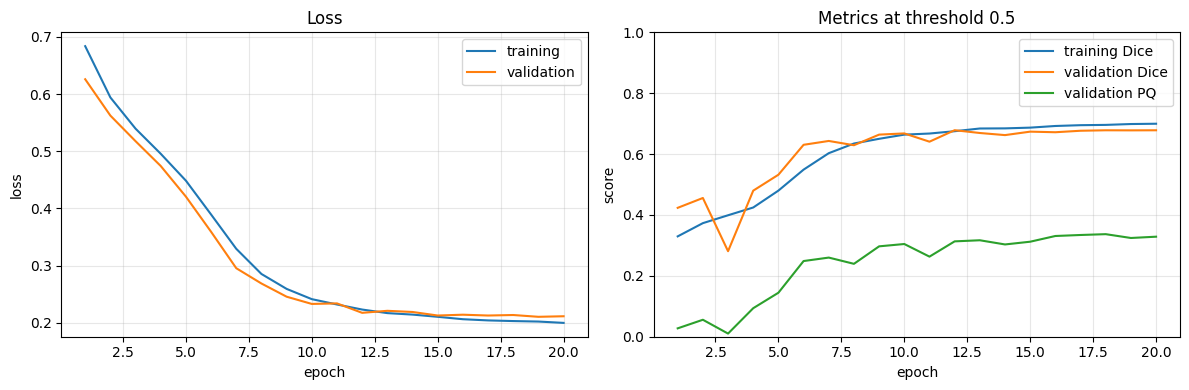

In [12]:
if history:
    epochs = [r["epoch"] for r in history]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, [r["train_loss"] for r in history], label="training")
    axes[0].plot(epochs, [r["validation_loss"] for r in history], label="validation")
    axes[0].set(title="Loss", xlabel="epoch", ylabel="loss")
    axes[1].plot(epochs, [r["train_dice"] for r in history], label="training Dice")
    axes[1].plot(epochs, [r["validation_dice"] for r in history], label="validation Dice")
    axes[1].plot(epochs, [r["validation_pq"] for r in history], label="validation PQ")
    axes[1].set(title="Metrics at threshold 0.5", xlabel="epoch", ylabel="score", ylim=(0, 1))
    for axis in axes:
        axis.grid(alpha=0.3); axis.legend()
    figure.tight_layout()
    figure.savefig(PLOTS_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

    import csv
    with (METRICS_DIR / "history.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(history[0]))
        writer.writeheader(); writer.writerows(history)

## 10. Choosing the operating point, against the official metric

The network outputs a probability per pixel; turning that into scored instances takes
four decisions, searched **jointly** on validation because they interact:

- the **threshold** that binarises the map;
- **closing**, which reconnects a filament the network split in two (two FP and one FN
  become one TP);
- a **minimum component size**, which removes the small spurious blobs that each count
  as a full false positive;
- a **confidence gate**: a component survives only if its probability peaks above the
  gate somewhere. This exists because the threshold alone does two jobs at once —
  deciding *which* blobs exist and *how fat* they are — and raising it to kill spurious
  blobs also thins every real filament. The gate takes over the first job.

Everything is scored at the native 2048×2048 with the official PQ, because that is where
the submission is written: the number of connected components is not preserved by
resizing a mask, and a minimum size tuned at 1536 means something else at 2048.

The search runs in two passes: a coarse grid, then a finer threshold/gate grid around
the coarse optimum (the threshold step of 0.05 is too coarse right where PQ peaks —
the refinement is worth about +0.003 PQ).

In [13]:
_D4 = ((lambda x: x, lambda x: x),
       (lambda x: torch.flip(x, [-1]), lambda x: torch.flip(x, [-1])),
       (lambda x: torch.flip(x, [-2]), lambda x: torch.flip(x, [-2])),
       (lambda x: torch.flip(x, [-1, -2]), lambda x: torch.flip(x, [-1, -2])),
       (lambda x: torch.rot90(x, 1, [-2, -1]), lambda x: torch.rot90(x, 3, [-2, -1])),
       (lambda x: torch.rot90(x, 2, [-2, -1]), lambda x: torch.rot90(x, 2, [-2, -1])),
       (lambda x: torch.rot90(x, 3, [-2, -1]), lambda x: torch.rot90(x, 1, [-2, -1])),
       (lambda x: torch.flip(torch.rot90(x, 1, [-2, -1]), [-1]),
        lambda x: torch.rot90(torch.flip(x, [-1]), 3, [-2, -1])))


@torch.inference_mode()
def predict_probabilities(model, images, runtime, tta=False):
    """Sigmoid probabilities, optionally averaged over the eight square symmetries."""
    model.eval()
    images = runtime.prepare(images)
    transforms = _D4 if tta else _D4[:1]
    total = None
    with runtime.autocast():
        for forward, inverse in transforms:
            p = torch.sigmoid(inverse(model(forward(images))).float())
            total = p if total is None else total + p
    runtime.note_memory()
    return (total / len(transforms)).cpu()


def _tile_offsets(extent, tile):
    """Window starts covering `extent`, the last one flush with the far edge."""
    if extent <= tile:
        return [0]
    offsets = list(range(0, extent - tile + 1, tile))
    if offsets[-1] != extent - tile:
        offsets.append(extent - tile)
    return offsets


def _blend_window(tile, margin=192):
    """A weight that fades towards a window's rim, so seams do not show.

    Two windows disagree slightly near their edges - different padding, different
    context - and a hard join leaves a visible line that connected components then read
    as a real boundary. Fading and normalising by the accumulated weight removes it. The
    floor of 0.05 keeps the frame's own border, covered by one window only, from being
    divided by nothing.
    """
    ramp = np.minimum(1.0, (np.arange(tile) + 0.5) / margin)
    ramp = 0.05 + 0.95 * np.minimum(ramp, ramp[::-1])
    return np.outer(ramp, ramp).astype(np.float32)


@torch.inference_mode()
def predict_frame(model, image, runtime, tile=None, tta=False):
    """Probabilities for one whole frame, in windows when the frame is too big.

    A 2048 forward pass holds 1.8x the activations of a 1536 one - measured, 4.50 GB
    against 2.50 GB - which puts the native frame over the 4 GB the assignment rewards.
    The network is fully convolutional and was trained on 1536 windows of this very
    frame, so evaluating overlapping 1536 windows and averaging them is the same
    computation at the same scale, with the peak bounded by one window instead of four.
    """
    frame = image.shape[-1]
    if not tile or tile >= frame:
        return predict_probabilities(model, image, runtime, tta=tta)[0, 0].numpy()
    total = np.zeros((frame, frame), dtype=np.float32)
    weight = np.zeros((frame, frame), dtype=np.float32)
    window = _blend_window(tile)
    for top in _tile_offsets(frame, tile):
        for left in _tile_offsets(frame, tile):
            patch = image[..., top:top + tile, left:left + tile]
            probability = predict_probabilities(model, patch, runtime, tta=tta)[0, 0].numpy()
            total[top:top + tile, left:left + tile] += probability * window
            weight[top:top + tile, left:left + tile] += window
    return total / np.maximum(weight, 1e-6)


def to_native(probability):
    """Enlarge a probability map to 2048 *before* it is thresholded.

    Thresholding first and enlarging a binary mask with nearest-neighbour interpolation
    quantises every boundary to a 2x2 block, and the number of connected components - the
    quantity PQ counts - is not preserved by resizing at all.
    """
    if probability.shape[-1] == NATIVE:
        return probability
    tensor = torch.from_numpy(probability)[None, None]
    return F.interpolate(tensor, size=(NATIVE, NATIVE), mode="bilinear",
                         align_corners=False)[0, 0].numpy()


def quantise(probability):
    """uint8 is plenty: the threshold grid steps by 0.05, 14x coarser than 1/255."""
    return np.clip(probability * 255.0 + 0.5, 0, 255).astype(np.uint8)


@torch.inference_mode()
def predict_native(model, samples, cache, runtime, image_size, tta=False, tile=None):
    """Probability maps at 2048x2048, one per unique observation."""
    unique = {}
    for sample in samples:
        unique.setdefault(Path(sample.file_name).stem, sample)
    maps = {}
    for stem in tqdm(unique, desc=f"native {NATIVE} maps", leave=False):
        image = cache.image(unique[stem].file_name).astype(np.float32) / 255.0
        frame = torch.from_numpy(image)[None, None]
        maps[stem] = quantise(to_native(predict_frame(model, frame, runtime, tile, tta)))
    return maps


def components_of(probability, threshold, close=0):
    """Label a thresholded map once, with the sizes every later filter needs."""
    mask = postprocess(probability >= int(round(threshold * 255)), 0, close)
    labels, count = ndimage.label(mask)
    areas = (np.bincount(labels.ravel(), minlength=count + 1)[1:] if count
             else np.zeros(0, dtype=np.int64))
    return labels, count, areas


def component_reaches(probability, labels, count, gate):
    """Which components contain a pixel at or above `gate`.

    This is the second filter of the operating point, and it exists because a single
    threshold was doing two conflicting jobs: it decides both which blobs exist
    (detection, which drives RQ) and how fat they are (shape, which drives Dice and SQ),
    so raising it to suppress specks also thins every real filament. Gating on the peak
    separates the two - a component survives only if the network is confident about it
    somewhere, and the survivors keep the outline the threshold gave them.

    Asked the obvious way, `ndimage.maximum` per component, this costs more than the
    labelling itself. Asked backwards - take the few pixels above the gate and see which
    components they landed in - it is ~40x cheaper, because at gate 0.95 only ~10k of the
    4.2M pixels qualify. Identical answer: a component reaches the gate exactly when at
    least one of those pixels belongs to it.
    """
    if count == 0:
        return np.zeros(0, dtype=bool)
    if not gate:
        return np.ones(count, dtype=bool)
    hot = labels[probability >= int(round(gate * 255))]
    return np.bincount(hot, minlength=count + 1)[1:] > 0


def surviving(count, areas, reaches, min_size=0):
    keep = np.array(reaches, dtype=bool, copy=True) if count else np.zeros(0, dtype=bool)
    if min_size and count:
        keep &= areas >= min_size
    return keep


def relabel(labels, keep, areas):
    """Renumber the survivors without running connected components again."""
    kept = int(keep.sum())
    lookup = np.zeros(keep.size + 1, dtype=labels.dtype)
    lookup[1:][keep] = np.arange(1, kept + 1, dtype=labels.dtype)
    return lookup[labels].ravel(), kept, areas[keep]


def predictions_at(maps, threshold, close=0, min_size=0, gate=0.0):
    """Label images for one operating point, in the shape the metrics expect."""
    out = {}
    for stem, probability in maps.items():
        labels, count, areas = components_of(probability, threshold, close)
        if count == 0:
            out[stem] = (labels.ravel(), 0, areas)
            continue
        reaches = component_reaches(probability, labels, count, gate)
        out[stem] = relabel(labels, surviving(count, areas, reaches, min_size), areas)
    return out


def overlap_tables(maps, ground_truth, threshold, close, gates):
    """Everything the metric needs from one thresholding, with the label images discarded.

    The grid then visits every (gate, minimum size) pair for this same thresholding, and
    those filters only ever *remove* components: they never alter the components
    themselves, nor how many pixels of a ground-truth instance fall inside one. So the
    overlap counts are computed once here and each later grid point becomes a handful of
    operations on a matrix with as many entries as there are filaments - instead of
    rebuilding a 2048x2048 label image for every observation, once per grid point.

    Only one label image is alive at a time, which is what keeps this inside a notebook's
    memory budget instead of several gigabytes of live int32 arrays.
    """
    entries_by_stem = defaultdict(list)
    for entry in ground_truth:
        entries_by_stem[entry["stem"]].append(entry)

    tables = []
    for stem, entries in entries_by_stem.items():
        probability = maps.get(stem)
        if probability is None:
            count, areas = 0, np.zeros(0, dtype=np.int64)
            flat, reaches = None, {gate: np.zeros(0, dtype=bool) for gate in gates}
        else:
            labels, count, areas = components_of(probability, threshold, close)
            reaches = {gate: component_reaches(probability, labels, count, gate)
                       for gate in gates}
            flat = labels.ravel()
        for entry in entries:
            sizes = np.array([index.size for index in entry["instances"]], dtype=np.int64)
            if count and sizes.size:
                overlap = np.stack([np.bincount(flat[index], minlength=count + 1)[1:]
                                    for index in entry["instances"]])
            else:
                overlap = np.zeros((sizes.size, count), dtype=np.int64)
            union = entry["union"]
            union_overlap = (np.bincount(flat[union], minlength=count + 1)[1:]
                             if count and union.size else np.zeros(count, dtype=np.int64))
            tables.append({"sizes": sizes, "overlap": overlap, "areas": areas,
                           "reaches": reaches, "count": count,
                           "union_size": int(union.size), "union_overlap": union_overlap})
        flat = None
    return tables


def score_tables(tables, min_size=0, gate=0.0, iou_threshold=0.5):
    """Dice and the official PQ for one (minimum size, gate), from precomputed overlaps.

    Identical arithmetic to `official_pq` and `mean_dice` - the same IoU > 0.5 rule, the
    same globally accumulated TP/FP/FN, the same Dice on the union of the instances -
    only without touching a full-resolution array.
    """
    matched_iou_sum, tp, false_positive, false_negative = 0.0, 0, 0, 0
    dice_scores = []
    for table in tables:
        keep = surviving(table["count"], table["areas"], table["reaches"][gate], min_size)
        areas = table["areas"][keep]
        n_pred, n_gt = int(keep.sum()), table["sizes"].size

        predicted_total = int(areas.sum())
        if table["union_size"] == 0 and predicted_total == 0:
            dice_scores.append(1.0)
        else:
            covered = int(table["union_overlap"][keep].sum())
            dice_scores.append((2 * covered + 1e-6)
                               / (table["union_size"] + predicted_total + 1e-6))

        if n_gt == 0:
            false_positive += n_pred
            continue
        if n_pred == 0:
            false_negative += n_gt
            continue
        inter = table["overlap"][:, keep]
        union = table["sizes"][:, None] + areas[None, :] - inter
        iou = np.zeros(inter.shape, dtype=float)
        np.divide(inter, np.maximum(union, 1), out=iou, where=union > 0)
        hit = iou > iou_threshold
        matched_iou_sum += float(iou[hit].sum())
        tp += int(hit.sum())
        false_positive += int((hit.sum(axis=0) == 0).sum())
        false_negative += int((hit.sum(axis=1) == 0).sum())

    denominator = tp + 0.5 * false_positive + 0.5 * false_negative
    return {"dice": float(np.mean(dice_scores)) if dice_scores else 0.0,
            "pq": (matched_iou_sum / denominator) if denominator else 0.0,
            "tp": tp, "fp": false_positive, "fn": false_negative,
            "mean_matched_iou": (matched_iou_sum / tp) if tp else 0.0}


def search_operating_point(maps, ground_truth,
                           thresholds=np.round(np.arange(0.30, 0.91, 0.05), 2),
                           closings=(0, 1, 2),
                           min_sizes=(0, 128, 192, 256, 320, 384, 448, 512, 640, 768, 1024),
                           gates=(0.0, 0.85, 0.95)):
    """Threshold, closing radius, minimum size and confidence gate, searched jointly.

    Jointly and not in sequence, because they interact: a sharper model tolerates a higher
    threshold alongside a more aggressive size filter, so tuning the threshold first locks
    in a worse point. The minimum-size grid is denser between 128 and 768 than a naive log
    spacing - experiment 08 showed the optimum can sit in a narrow band there (256 too
    permissive, 512 already too aggressive, 384 the real optimum) and a sparse grid misses
    it by a wide margin.

    Cost is dominated by the thresholding and labelling, so the loops are ordered to pay
    that once per (threshold, closing) and reuse it for all 33 (gate, minimum size) pairs.
    """
    rows = []
    gates = tuple(float(g) for g in gates)
    with tqdm(total=len(thresholds) * len(closings), desc="operating point",
              leave=False) as bar:
        for threshold in thresholds:
            for close in closings:
                tables = overlap_tables(maps, ground_truth, float(threshold), close, gates)
                for gate in gates:
                    for min_size in min_sizes:
                        rows.append({"threshold": float(threshold), "close": close,
                                     "min_size": min_size, "gate": gate,
                                     **score_tables(tables, min_size, gate)})
                bar.update(1)
    return rows


def selection_key(row, objective="balanced"):
    """Stable ordering shared by operating-point and checkpoint selection."""
    keys = {"pq": lambda r: (r["pq"], r["dice"]),
            "dice": lambda r: (r["dice"], r["pq"]),
            "balanced": lambda r: (r["pq"] + r["dice"], r["dice"])}
    return keys[objective](row)


def select(grid, objective="balanced"):
    """`balanced` maximises Dice + PQ: the course grades Dice, Kaggle reports PQ."""
    return max(grid, key=lambda row: selection_key(row, objective))

In [14]:
ground_truth = build_ground_truth(by_split["validation"])
print(f"{len(ground_truth)} annotator-image entries, "
      f"{sum(len(e['instances']) for e in ground_truth)} ground-truth filaments")

# Dice and the cheap per-epoch PQ often peak at different epochs. Evaluate both
# checkpoints with the real tiled+D4 pipeline and the full official operating-point
# search; only that comparison decides what the inference notebook will load.
candidates = [("best_dice", BEST_DICE_CHECKPOINT),
              ("best_cheap_pq", BEST_PQ_CHECKPOINT)]
candidates = [(label, path) for label, path in candidates if path.is_file()]
if not candidates:
    raise FileNotFoundError("no checkpoint candidates found")

candidate_summaries, seen_epochs = [], set()
selected_checkpoint = selected_metadata = selected_grid = selected_maps = None
selected_operating_point = None
for label, checkpoint in candidates:
    metadata = load_checkpoint(model, checkpoint, runtime.device)
    epoch = int(metadata.get("epoch", -1))
    if epoch in seen_epochs:
        print(f"skip {label}: same epoch {epoch} already evaluated")
        continue
    seen_epochs.add(epoch)
    model = runtime.prepare(model).eval()
    started = time.perf_counter()
    candidate_maps = predict_native(model, by_split["validation"], cache, runtime,
                                    IMAGE_SIZE, tta=RUN_TTA, tile=INFERENCE_TILE)
    candidate_grid = search_operating_point(candidate_maps, ground_truth)
    # second, finer pass around the region where the coarse grid peaks: the 0.05
    # threshold step is too coarse exactly there, and the refinement is worth
    # about +0.003 PQ at no training cost
    candidate_grid += search_operating_point(
        candidate_maps, ground_truth,
        thresholds=(0.40, 0.42, 0.45, 0.48, 0.50),
        closings=(0, 1),
        min_sizes=(320, 352, 384, 416, 448),
        gates=(0.90, 0.95, 0.97))
    best = {objective: select(candidate_grid, objective)
            for objective in ("dice", "pq", "balanced")}
    elapsed = time.perf_counter() - started
    candidate_summaries.append({"label": label, "epoch": epoch,
                                "checkpoint": str(checkpoint.relative_to(PROJECT_ROOT)),
                                "best": best, "seconds": elapsed})
    row = best[SELECTION_OBJECTIVE]
    print(f"{label:13s} epoch {epoch:02d}: Dice {row['dice']:.4f}  "
          f"PQ {row['pq']:.4f}  ({elapsed:.0f}s, {len(candidate_grid)} combinations)")
    if (selected_operating_point is None or
            selection_key(row, SELECTION_OBJECTIVE) >
            selection_key(selected_operating_point, SELECTION_OBJECTIVE)):
        selected_checkpoint, selected_metadata = checkpoint, metadata
        selected_grid, selected_maps = candidate_grid, candidate_maps
        selected_operating_point = row
    else:
        candidate_grid = candidate_maps = None

if selected_checkpoint is None:
    raise RuntimeError("checkpoint comparison produced no result")
load_checkpoint(model, selected_checkpoint, runtime.device)
model = runtime.prepare(model).eval()
grid, validation_maps, operating_point = selected_grid, selected_maps, selected_operating_point
print(f"\nselected checkpoint: {selected_checkpoint.name} "
      f"(epoch {selected_metadata.get('epoch')}, objective={SELECTION_OBJECTIVE})")

for objective in ("dice", "pq", "balanced"):
    row = select(grid, objective)
    marker = "  <- selected" if objective == SELECTION_OBJECTIVE else ""
    print(f"best {objective:9s}: t={row['threshold']:.2f} close={row['close']} "
          f"min_size={row['min_size']:5d} gate={row['gate']:.2f} -> "
          f"Dice {row['dice']:.4f}  PQ {row['pq']:.4f}"
          f"  (TP {row['tp']} FP {row['fp']} FN {row['fn']}){marker}")

ungated = select([r for r in grid if r["gate"] == 0.0], SELECTION_OBJECTIVE)
print(f"\nbest without the confidence gate: Dice {ungated['dice']:.4f}  PQ {ungated['pq']:.4f}"
      f"  (TP {ungated['tp']} FP {ungated['fp']} FN {ungated['fn']})")

save_json({"selected": operating_point, "objective": SELECTION_OBJECTIVE,
           "selected_checkpoint": str(selected_checkpoint.relative_to(PROJECT_ROOT)),
           "checkpoint_candidates": candidate_summaries, "grid": grid},
          METRICS_DIR / "operating_point.json")

recipe = {"experiment_id": EXPERIMENT_ID, "model": MODEL_NAME,
          "checkpoint": str(selected_checkpoint.relative_to(PROJECT_ROOT)),
          "checkpoint_epoch": int(selected_metadata.get("epoch", -1)),
          "selection_objective": SELECTION_OBJECTIVE,
          "image_size": IMAGE_SIZE, "tile": INFERENCE_TILE,
          "threshold": operating_point["threshold"],
          "close": operating_point["close"], "min_size": operating_point["min_size"],
          "gate": operating_point["gate"],
          "tta": bool(RUN_TTA), "validation_dice": operating_point["dice"],
          "validation_pq": operating_point["pq"]}
save_json(recipe, METRICS_DIR / "submission_recipe.json")
print("\n" + json.dumps(recipe, indent=2))

official ground truth:   0%|          | 0/169 [00:00<?, ?it/s]

169 annotator-image entries, 1144 ground-truth filaments


native 2048 maps:   0%|          | 0/106 [00:00<?, ?it/s]

operating point:   0%|          | 0/39 [00:00<?, ?it/s]

operating point:   0%|          | 0/10 [00:00<?, ?it/s]

best_dice     epoch 12: Dice 0.6769  PQ 0.4198  (586s, 1437 combinations)


native 2048 maps:   0%|          | 0/106 [00:00<?, ?it/s]

operating point:   0%|          | 0/39 [00:00<?, ?it/s]

operating point:   0%|          | 0/10 [00:00<?, ?it/s]

best_cheap_pq epoch 18: Dice 0.6709  PQ 0.4197  (582s, 1437 combinations)

selected checkpoint: best_model.pt (epoch 12, objective=pq)
best dice     : t=0.85 close=2 min_size=    0 gate=0.95 -> Dice 0.6781  PQ 0.3869  (TP 744 FP 695 FN 400)
best pq       : t=0.80 close=0 min_size=  320 gate=0.95 -> Dice 0.6769  PQ 0.4198  (TP 738 FP 475 FN 406)  <- selected
best balanced : t=0.80 close=0 min_size=  320 gate=0.95 -> Dice 0.6769  PQ 0.4198  (TP 738 FP 475 FN 406)

best without the confidence gate: Dice 0.6771  PQ 0.4190  (TP 740 FP 483 FN 404)

{
  "experiment_id": "15",
  "checkpoint": "experiments/15/checkpoints/best_model.pt",
  "checkpoint_epoch": 12,
  "selection_objective": "pq",
  "image_size": 1536,
  "tile": null,
  "threshold": 0.8,
  "close": 0,
  "min_size": 320,
  "gate": 0.95,
  "tta": true,
  "validation_dice": 0.6768689690394102,
  "validation_pq": 0.4197971965005265
}


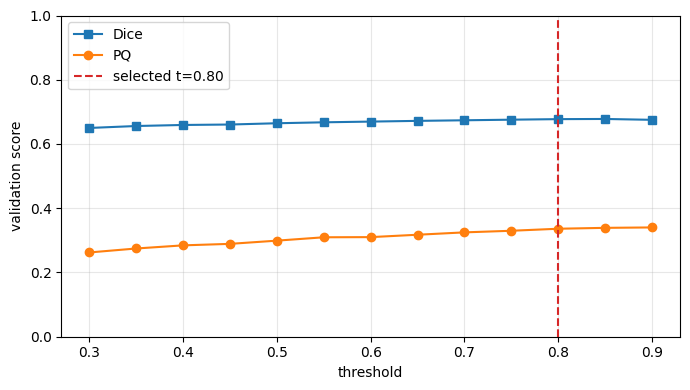

In [15]:
# one point per threshold: no closing, no size filter, no gate - the raw curve
curve = sorted([r for r in grid if r["close"] == 0 and r["min_size"] == 0
                and r["gate"] == 0.0], key=lambda r: r["threshold"])
figure, axis = plt.subplots(figsize=(7, 4))
axis.plot([r["threshold"] for r in curve], [r["dice"] for r in curve], marker="s", label="Dice")
axis.plot([r["threshold"] for r in curve], [r["pq"] for r in curve], marker="o", label="PQ")
axis.axvline(operating_point["threshold"], color="tab:red", linestyle="--",
             label=f"selected t={operating_point['threshold']:.2f}")
axis.set(xlabel="threshold", ylabel="validation score", ylim=(0, 1))
axis.grid(alpha=0.3); axis.legend()
figure.tight_layout()
figure.savefig(PLOTS_DIR / "threshold_search.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Where the error actually is

A single PQ number does not say what to fix next. This cell breaks the error down:
instance recall by filament size, and *why* each false negative (missed completely /
found but too small / split) and each false positive (hallucination / on an annotated
but unmatched filament / merge) happened. These counts are what decided the next
experiment at every step of the project.

In [16]:
predictions = predictions_at(validation_maps, operating_point["threshold"],
                             operating_point["close"], operating_point["min_size"],
                             operating_point["gate"])

buckets = [(0, 500), (500, 1000), (1000, 2000), (2000, 5000), (10 ** 9,)]
edges = [(0, 500), (500, 1000), (1000, 2000), (2000, 5000), (5000, 10 ** 9)]
found = {b: 0 for b in edges}
total = {b: 0 for b in edges}
for entry in ground_truth:
    labels, n_pred, pred_areas = predictions.get(entry["stem"], (None, 0, np.zeros(0)))
    for index in entry["instances"]:
        bucket = next(b for b in edges if b[0] <= index.size < b[1])
        total[bucket] += 1
        if n_pred:
            counts = np.bincount(labels[index], minlength=n_pred + 1)[1:]
            union = index.size + pred_areas - counts
            if (np.divide(counts, np.maximum(union, 1)) > 0.5).any():
                found[bucket] += 1

print(f"{'filament size (px @2048)':>26} {'total':>6} {'matched':>8} {'recall':>7}")
recall_rows = []
for bucket in edges:
    if not total[bucket]:
        continue
    label = f"{bucket[0]}-{bucket[1]}" if bucket[1] < 10 ** 8 else f">{bucket[0]}"
    recall = found[bucket] / total[bucket]
    print(f"{label:>26} {total[bucket]:>6} {found[bucket]:>8} {recall:>7.2f}")
    recall_rows.append({"range": label, "total": total[bucket],
                        "matched": found[bucket], "recall": recall})
overall = sum(found.values()) / max(sum(total.values()), 1)
print(f"\noverall instance recall: {overall:.3f}")
denominator = (operating_point["tp"] + 0.5 * operating_point["fp"]
               + 0.5 * operating_point["fn"])
sq = operating_point["mean_matched_iou"]
rq = operating_point["tp"] / denominator if denominator else 0.0
print(f"TP {operating_point['tp']}  FP {operating_point['fp']}  FN {operating_point['fn']}  "
      f"SQ {sq:.4f}  RQ {rq:.4f}  (PQ = SQ x RQ = {sq * rq:.4f})")


def error_causes(ground_truth, predictions, iou_threshold=0.5):
    """Why each FN and FP happened, in the operational sense that decides what to
    build next.

    FN: `pure_miss` - not one predicted pixel on the instance; `split` - no single
    prediction reaches the IoU gate but the union of the overlapping ones does;
    `near_miss` - one prediction overlaps but stays at IoU <= 0.5 (its
    predicted/true area ratio is recorded). FP: `hallucination` - the prediction
    touches no ground-truth pixel of that annotator entry; `merge` - it overlaps
    two or more instances and clears the gate against their union; `unmatched` -
    it overlaps annotated filament pixels without matching any single instance.
    """
    fn = {"pure_miss": 0, "near_miss": 0, "split": 0}
    fp = {"hallucination": 0, "merge": 0, "unmatched": 0}
    near_miss_area_ratio = []
    for entry in ground_truth:
        labels, n_pred, pred_areas = predictions.get(
            entry["stem"], (None, 0, np.zeros(0, dtype=np.int64)))
        union_index = entry["union"]
        n_gt = len(entry["instances"])
        if n_pred == 0:
            fn["pure_miss"] += n_gt
            continue
        overlap = (np.stack([np.bincount(labels[ix], minlength=n_pred + 1)[1:]
                             for ix in entry["instances"]])
                   if n_gt else np.zeros((0, n_pred), dtype=np.int64))
        sizes = np.array([ix.size for ix in entry["instances"]], dtype=np.int64)
        iou = np.zeros(overlap.shape)
        if n_gt:
            denom = sizes[:, None] + pred_areas[None, :] - overlap
            np.divide(overlap, np.maximum(denom, 1), out=iou, where=denom > 0)
        hit = iou > iou_threshold
        for i in range(n_gt):
            if hit[i].any():
                continue
            touching = overlap[i] > 0
            if not touching.any():
                fn["pure_miss"] += 1
                continue
            inter = int(overlap[i].sum())
            union = int(sizes[i] + pred_areas[touching].sum() - inter)
            if touching.sum() >= 2 and inter / max(union, 1) > iou_threshold:
                fn["split"] += 1
            else:
                fn["near_miss"] += 1
                best = int(np.argmax(iou[i]))
                near_miss_area_ratio.append(float(pred_areas[best] / max(sizes[i], 1)))
        gt_cover = (np.bincount(labels[union_index], minlength=n_pred + 1)[1:]
                    if union_index.size else np.zeros(n_pred, dtype=np.int64))
        for j in range(n_pred):
            if n_gt and hit[:, j].any():
                continue
            if gt_cover[j] == 0:
                fp["hallucination"] += 1
                continue
            touching = overlap[:, j] > 0 if n_gt else np.zeros(0, bool)
            if touching.sum() >= 2:
                inter = int(overlap[touching, j].sum())
                union = int(sizes[touching].sum() + pred_areas[j] - inter)
                if inter / max(union, 1) > iou_threshold:
                    fp["merge"] += 1
                    continue
            fp["unmatched"] += 1
    ratio = (float(np.median(near_miss_area_ratio))
             if near_miss_area_ratio else float("nan"))
    return fn, fp, ratio


fn_causes, fp_causes, near_miss_ratio = error_causes(ground_truth, predictions)
print(f"FN causes: {fn_causes}  (near-miss median predicted/true area {near_miss_ratio:.2f})")
print(f"FP causes: {fp_causes}")
save_json({"recall_by_size": recall_rows, "overall_instance_recall": overall,
           "sq": sq, "rq": rq,
           "fn_causes": fn_causes, "fp_causes": fp_causes,
           "near_miss_median_area_ratio": near_miss_ratio,
           "operating_point": operating_point}, METRICS_DIR / "error_analysis.json")

  filament size (px @2048)  total  matched  recall
                     0-500    183       68    0.37
                  500-1000    296      193    0.65
                 1000-2000    286      203    0.71
                 2000-5000    284      202    0.71
                     >5000     95       72    0.76

overall instance recall: 0.645
TP 738  FP 475  FN 406  SQ 0.6704  RQ 0.6262  (PQ = SQ x RQ = 0.4198)
FN causes: {'pure_miss': 189, 'near_miss': 181, 'split': 36}  (near-miss median predicted/true area 0.95)
FP causes: {'hallucination': 195, 'merge': 13, 'unmatched': 267}


## 11b. The distributions the judging committee looks at

The organisers' self-evaluation notebook plots, besides PQ, the distribution of IoU
and Dice over every overlapping ground-truth/prediction pair and the **many-to-one /
one-to-many relations** — how many partners each instance touches. The judging
committee reads these alongside the score, so they are reproduced here with the same
conventions: pairs with zero overlap are dropped, and a "hit" is any overlap at all
(not the IoU > 0.5 gate of the metric).


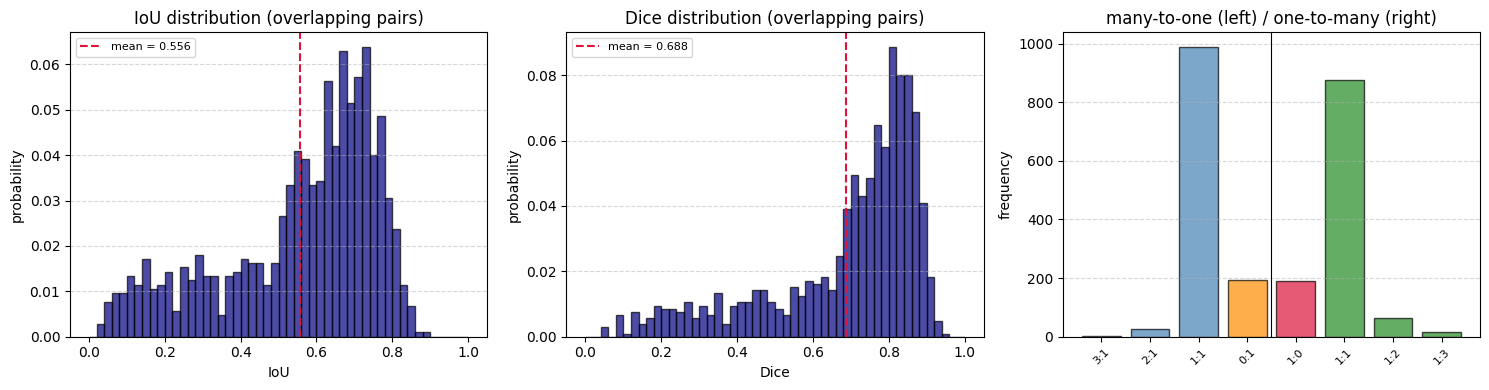

GT instances:   955 touched by >=1 prediction, 189 untouched
predictions:    1018 touching >=1 GT instance, 195 touching none
one-to-many GT (1:n, n>=2): 79 | many-to-one predictions (n:1, n>=2): 29


In [17]:
iou_pairs, dice_pairs = [], []
gt_degrees, pred_degrees = [], []
for entry in ground_truth:
    labels, n_pred, pred_areas = predictions.get(
        entry["stem"], (None, 0, np.zeros(0, dtype=np.int64)))
    sizes = np.array([index.size for index in entry["instances"]], dtype=np.int64)
    n_gt = sizes.size
    if n_gt == 0:
        pred_degrees.extend([0] * n_pred)
        continue
    if n_pred == 0:
        gt_degrees.extend([0] * n_gt)
        continue
    inter = np.stack([np.bincount(labels[index], minlength=n_pred + 1)[1:]
                      for index in entry["instances"]])
    total = sizes[:, None] + pred_areas[None, :]
    union = total - inter
    iou = np.zeros(inter.shape)
    np.divide(inter, np.maximum(union, 1), out=iou, where=union > 0)
    dice = np.zeros(inter.shape)
    np.divide(2 * inter, np.maximum(total, 1), out=dice, where=union > 0)
    hit = inter > 0
    iou_pairs.extend(iou[hit].tolist())
    dice_pairs.extend(dice[hit].tolist())
    gt_degrees.extend(hit.sum(axis=1).tolist())
    pred_degrees.extend(hit.sum(axis=0).tolist())

from collections import Counter as _Counter
gt_deg, pred_deg = _Counter(gt_degrees), _Counter(pred_degrees)

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, scores, name in ((axes[0], iou_pairs, "IoU"), (axes[1], dice_pairs, "Dice")):
    scores = np.asarray(scores)
    counts, edges = np.histogram(scores, bins=np.linspace(0, 1, 51))
    axis.bar((edges[:-1] + edges[1:]) / 2, counts / max(counts.sum(), 1), width=0.02,
             edgecolor="black", alpha=0.7, color="navy")
    axis.axvline(scores.mean(), color="crimson", linestyle="--",
                 label=f"mean = {scores.mean():.3f}")
    axis.set(title=f"{name} distribution (overlapping pairs)", xlabel=name,
             ylabel="probability")
    axis.grid(axis="y", linestyle="--", alpha=0.5); axis.legend(fontsize=8)

axis = axes[2]
for degree, count in sorted(gt_deg.items()):
    axis.bar(degree + 0.5, count, width=0.8, edgecolor="black", alpha=0.7,
             color="crimson" if degree == 0 else "forestgreen")
for degree, count in sorted(pred_deg.items()):
    axis.bar(-(degree + 0.5), count, width=0.8, edgecolor="black", alpha=0.7,
             color="darkorange" if degree == 0 else "steelblue")
positions = ([d + 0.5 for d in sorted(gt_deg)]
             + [-(d + 0.5) for d in sorted(pred_deg)])
axis.set_xticks(positions)
axis.set_xticklabels([f"1:{int(round(p - 0.5))}" if p > 0 else
                      f"{int(round(-p - 0.5))}:1" for p in positions],
                     rotation=45, fontsize=8)
axis.axvline(0, color="black", linewidth=0.8)
axis.set(title="many-to-one (left) / one-to-many (right)", ylabel="frequency")
axis.grid(axis="y", linestyle="--", alpha=0.5)
figure.tight_layout()
figure.savefig(PLOTS_DIR / "official_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

gt_hit = sum(c for d, c in gt_deg.items() if d > 0)
pred_hit = sum(c for d, c in pred_deg.items() if d > 0)
print(f"GT instances:   {gt_hit} touched by >=1 prediction, {gt_deg.get(0, 0)} untouched")
print(f"predictions:    {pred_hit} touching >=1 GT instance, {pred_deg.get(0, 0)} touching none")
print(f"one-to-many GT (1:n, n>=2): {sum(c for d, c in gt_deg.items() if d >= 2)}"
      f" | many-to-one predictions (n:1, n>=2): {sum(c for d, c in pred_deg.items() if d >= 2)}")
save_json({"gt_degree_counts": {str(k): v for k, v in sorted(gt_deg.items())},
           "pred_degree_counts": {str(k): v for k, v in sorted(pred_deg.items())},
           "mean_pair_iou": float(np.mean(iou_pairs)) if iou_pairs else 0.0,
           "mean_pair_dice": float(np.mean(dice_pairs)) if dice_pairs else 0.0},
          METRICS_DIR / "official_distributions.json")

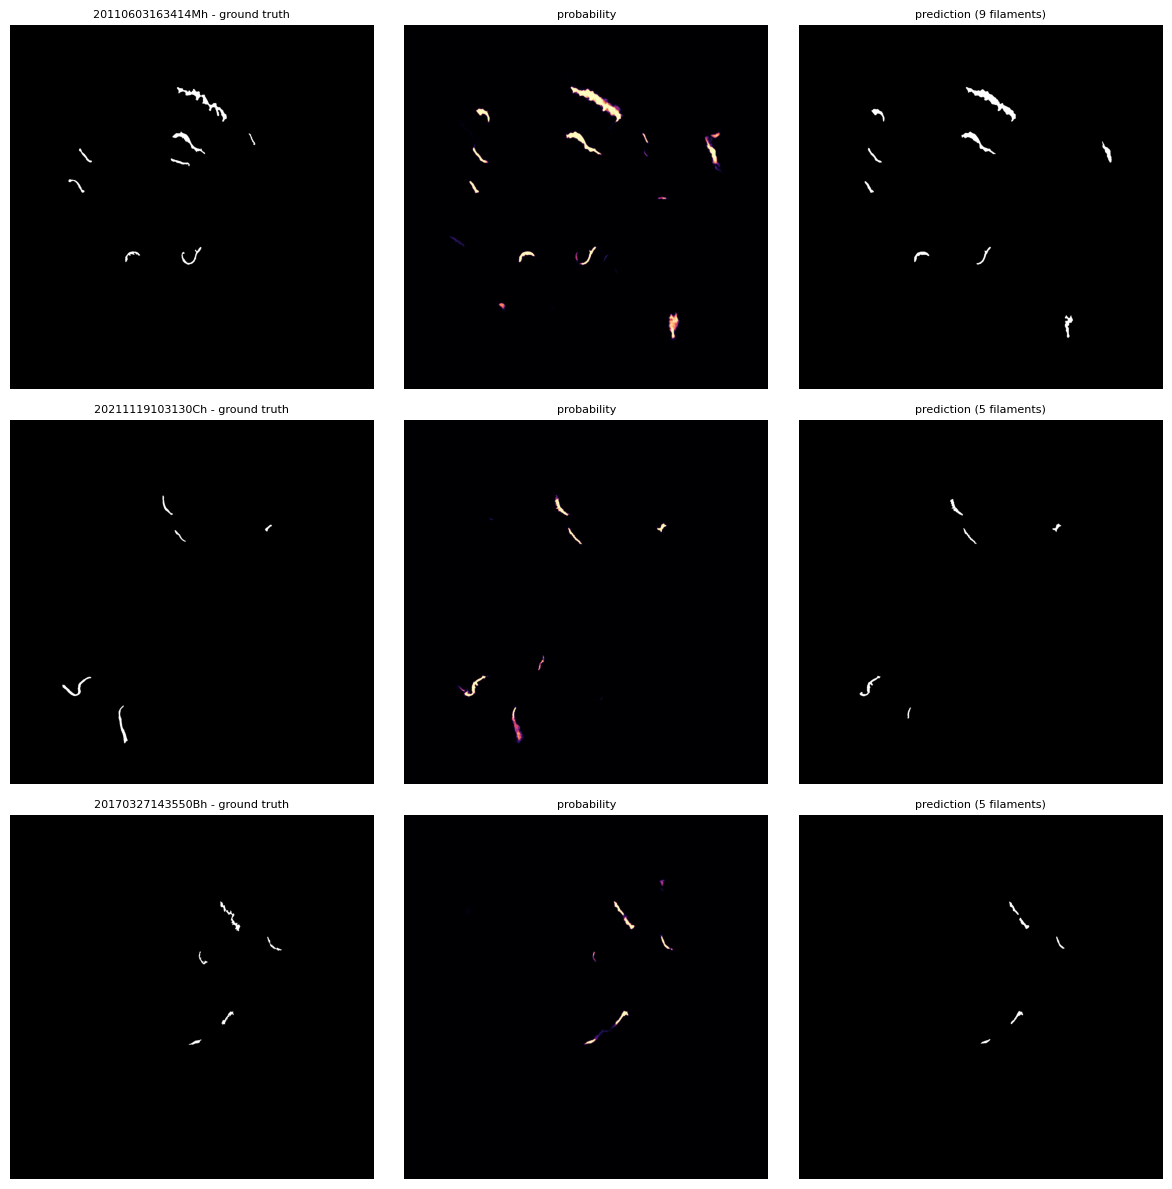

In [18]:
stems = list(validation_maps)[:3]
figure, axes = plt.subplots(len(stems), 3, figsize=(12, 4 * len(stems)), squeeze=False)
for row, stem in enumerate(stems):
    probability = validation_maps[stem] / 255.0
    labels, count, _ = predictions[stem]
    prediction = (labels > 0).reshape(NATIVE, NATIVE)
    entry = next(e for e in ground_truth if e["stem"] == stem)
    truth = np.zeros(NATIVE * NATIVE, dtype=bool)
    for index in entry["instances"]:
        truth[index] = True
    axes[row, 0].imshow(truth.reshape(NATIVE, NATIVE), cmap="gray")
    axes[row, 0].set_title(f"{stem} - ground truth", fontsize=8)
    axes[row, 1].imshow(probability, cmap="magma", vmin=0, vmax=1)
    axes[row, 1].set_title("probability", fontsize=8)
    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title(f"prediction ({count} filaments)", fontsize=8)
    for axis in axes[row]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(PLOTS_DIR / "validation_predictions.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. The internal test set

Consulted **once**, with the model, threshold and post-processing already frozen —
every extra look would turn it into a second validation set. From experiment 07 on the
internal test split is folded into training instead (`TRAIN_ON_TEST_SPLIT`), which is
legitimate exactly because it is never used to choose anything.

In [19]:
test_metrics = None
if RUN_FINAL_TEST:
    test_truth = build_ground_truth(by_split["test"])
    test_maps = predict_native(model, by_split["test"], cache, runtime, IMAGE_SIZE,
                               tta=RUN_TTA, tile=INFERENCE_TILE)
    test_predictions = predictions_at(test_maps, operating_point["threshold"],
                                      operating_point["close"], operating_point["min_size"],
                                      operating_point["gate"])
    test_metrics = {"dice": mean_dice(test_truth, test_predictions),
                    **official_pq(test_truth, test_predictions)}
    save_json({"recipe": recipe, "metrics": test_metrics}, METRICS_DIR / "test_metrics.json")
    print(f"internal test : Dice {test_metrics['dice']:.4f}  PQ {test_metrics['pq']:.4f}")
    print(f"validation    : Dice {operating_point['dice']:.4f}  PQ {operating_point['pq']:.4f}")
else:
    print("internal test not consulted (RUN_FINAL_TEST = False).")

summary = {"experiment_id": EXPERIMENT_ID, "training": training_summary,
           "operating_point": recipe, "test_metrics": test_metrics}
save_json(summary, EXPERIMENT_DIR / "summary.json")
print(f"\nNext: open 02_inference.ipynb with EXPERIMENT_ID = \"{EXPERIMENT_ID}\".")

internal test not consulted (RUN_FINAL_TEST = False).

Next: open 02_inference.ipynb with EXPERIMENT_ID = "15".
